# Dataset 1: Daily Activities and Sports Dataset

# 0. Fuentes

La base de datos se puede obtener en el siguiente enlace:

https://archive.ics.uci.edu/dataset/256/daily+and+sports+activities

El artículo del paper se puede obtener en el siguiente enlace:

https://yoksis.bilkent.edu.tr/pdf/files/10.1016-j.patcog.2010.04.019.pdf

Las actividaes son:

The 19 activities are: 

- sitting (A1), 
- standing (A2), 
- lying on back and on right side (A3 and A4), 
- ascending and descending stairs (A5 and A6), 
- standing in an elevator still (A7) 
- and moving around in an elevator (A8), 
- walking in a parking lot (A9), 
- walking on a treadmill with a speed of 4 km/h (in flat and 15 deg inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12), 
- exercising on a stepper (A13), 
- exercising on a cross trainer (A14), 
- cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17), 
- jumping (A18), 
- and playing basketball (A19).

# 1. Primera entrega: EDA y pre-procesamiento

## 1.1.    Cargar los datos

Llamamos a las librerías para importar los datos:

- pandas:
- os: 

In [12]:
import pandas as pd
pd.set_option("display.float_format", "{:.3f}".format)

import os

In [13]:
from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass


class DataLoaderDSA(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for activity in os.listdir(self.src_path):
            act_path = f"{self.src_path}/{activity}"
            for person in os.listdir(act_path):
                person_path = f"{self.src_path}/{activity}/{person}"
                for segment in os.listdir(person_path):
                    segment_path = f"{self.src_path}/{activity}/{person}/{segment}"
                    if self._is_valid_extension(segment):  
                        segment_features = pd.read_csv(segment_path, delimiter=self.delimiter, names=self.keys)
                        segment_features['activity_label'] = activity
                        segment_features['person_id'] = person
                        segment_features['segment'] = f"{activity}{person}{segment}"
                        dataframes.append(segment_features)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df
    
                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)


dsa_path = "dataset/dsaa/data"

keys = [
    # Tronco (T)
    "T_xacc", "T_yacc", "T_zacc", "T_xgyro", "T_ygyro", "T_zgyro", "T_xmag", "T_ymag", "T_zmag",
    
    # Brazo derecho (RA)
    "RA_xacc", "RA_yacc", "RA_zacc", "RA_xgyro", "RA_ygyro", "RA_zgyro", "RA_xmag", "RA_ymag", "RA_zmag",
    
    # Brazo izquierdo (LA)
    "LA_xacc", "LA_yacc", "LA_zacc", "LA_xgyro", "LA_ygyro", "LA_zgyro", "LA_xmag", "LA_ymag", "LA_zmag",
    
    # Pierna derecha (RL)
    "RL_xacc", "RL_yacc", "RL_zacc", "RL_xgyro", "RL_ygyro", "RL_zgyro", "RL_xmag", "RL_ymag", "RL_zmag",
    
    # Pierna izquierda (LL)
    "LL_xacc", "LL_yacc", "LL_zacc", "LL_xgyro", "LL_ygyro", "LL_zgyro", "LL_xmag", "LL_ymag", "LL_zmag"
]

file_extension = '.txt'
delimiter = r','
data_loader = DataLoaderDSA(dsa_path, keys, file_extension, delimiter)

dsa_df = data_loader.load_data()

## 1.2. Dimensiones y primeras 5 filas

Dimensiones

In [16]:
dsa_df.shape

(1140000, 48)

Primeras 5 filas

In [18]:
dsa_df.head()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,...,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,...,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,...,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,...,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,...,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt


## 1.3. Identifica y elimina los datos ausentes

In [20]:
dsa_df.isnull().sum()

T_xacc            0
T_yacc            0
T_zacc            0
T_xgyro           0
T_ygyro           0
T_zgyro           0
T_xmag            0
T_ymag            0
T_zmag            0
RA_xacc           0
RA_yacc           0
RA_zacc           0
RA_xgyro          0
RA_ygyro          0
RA_zgyro          0
RA_xmag           0
RA_ymag           0
RA_zmag           0
LA_xacc           0
LA_yacc           0
LA_zacc           0
LA_xgyro          0
LA_ygyro          0
LA_zgyro          0
LA_xmag           0
LA_ymag           0
LA_zmag           0
RL_xacc           0
RL_yacc           0
RL_zacc           0
RL_xgyro          0
RL_ygyro          0
RL_zgyro          0
RL_xmag           0
RL_ymag           0
RL_zmag           0
LL_xacc           0
LL_yacc           0
LL_zacc           0
LL_xgyro          0
LL_ygyro          0
LL_zgyro          0
LL_xmag           0
LL_ymag           0
LL_zmag           0
activity_label    0
person_id         0
segment           0
dtype: int64

## 1.4. Presenta los tipos de datos de cada atributo de cada base de datos

In [22]:
dsa_df.dtypes

T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag           float64
LL_xacc           float64
LL_yacc           float64
LL_zacc     

## 1.5. Presenta el resumen estadístico de cada uno de los atributos de cada base de datos

In [24]:
pd.set_option('display.max_columns', None)  
dsa_df.describe().T

,count,mean,std,min,25%,50%,75%,max
T_xacc,1140000.000,7.766,5.638,-99.715,6.907,8.830,9.691,93.694
T_yacc,1140000.000,-0.811,2.623,-49.941,-1.510,-0.390,0.414,41.013
T_zacc,1140000.000,2.769,3.538,-62.664,0.900,2.704,4.405,120.530
T_xgyro,1140000.000,-0.003,0.794,-27.851,-0.163,0.000,0.165,27.671
T_ygyro,1140000.000,0.014,0.691,-23.598,-0.102,0.017,0.131,14.379
T_zgyro,1140000.000,-0.003,0.311,-12.067,-0.097,-0.003,0.089,19.262
T_xmag,1140000.000,-0.598,0.356,-1.423,-0.825,-0.690,-0.493,1.022
T_ymag,1140000.000,0.062,0.340,-1.023,-0.179,0.022,0.282,1.031
T_zmag,1140000.000,-0.273,0.373,-1.081,-0.602,-0.309,0.041,0.963
RA_xacc,1140000.000,4.261,5.821,-49.535,0.095,4.143,8.505,71.652


## 1.6. Presenta la distribución de clases de cada base de datos

Por convención a las actividaes se les asigna un label alfanumérico. A continuación se presenta la correspondencia entre estos y las actividades que representan:

- sitting (A1),
- standing (A2),
- lying on back and on right side (A3 and A4),
- ascending and descending stairs (A5 and A6),
- standing in an elevator still (A7) and moving around (A8),
- walking in a parking lot (A9),
- walking on a treadmill with a speed of 4 km/h (in flat and 151 inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12),
- exercising on a stepper (A13),
- exercising on a cross trainer (A14), cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17),
- jumping (A18),
- playing basketball (A19).

In [27]:
dsa_class_distribution = dsa_df['activity_label'].value_counts()
dsa_class_distribution

activity_label
a01    60000
a11    60000
a18    60000
a17    60000
a16    60000
a15    60000
a14    60000
a13    60000
a12    60000
a10    60000
a02    60000
a09    60000
a08    60000
a07    60000
a06    60000
a05    60000
a04    60000
a03    60000
a19    60000
Name: count, dtype: int64

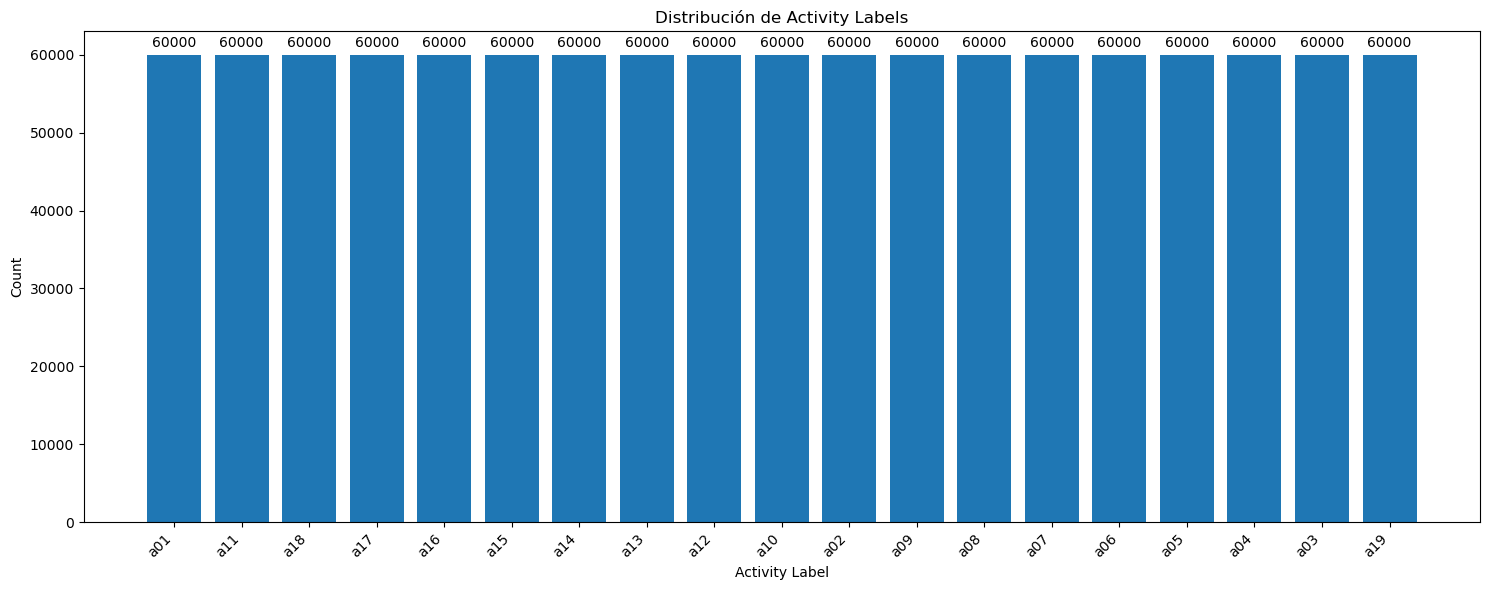

In [28]:
import matplotlib.pyplot as plt

dsa_class_distribution = dsa_df['activity_label'].value_counts()

plt.figure(figsize=(15, 6))
bars = plt.bar(dsa_class_distribution.index, dsa_class_distribution.values)

plt.xlabel('Activity Label')
plt.ylabel('Count')
plt.title('Distribución de Activity Labels')

# Agregar la cantidad exacta en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height * 1.01, f'{int(height)}', ha='center', va='bottom')

# Rotar etiquetas del eje X y ajustar el tamaño de la fuente
plt.xticks(rotation=45, ha='right', fontsize=10)

# Ajustar los márgenes para que las etiquetas no se recorten
plt.subplots_adjust(bottom=0.25)

plt.tight_layout()
plt.show()


## 1.7. Presenta la correlación entre atributos de cada base de datos

In [30]:
non_sensor_columns = ["activity_label", "person_id", "segment"]

only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

dsa_corr_matrix = only_sensor_columns.iloc[:, :].corr(method = "pearson")
dsa_corr_matrix

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,RA_yacc,RA_zacc,RA_xgyro,RA_ygyro,RA_zgyro,RA_xmag,RA_ymag,RA_zmag,LA_xacc,LA_yacc,LA_zacc,LA_xgyro,LA_ygyro,LA_zgyro,LA_xmag,LA_ymag,LA_zmag,RL_xacc,RL_yacc,RL_zacc,RL_xgyro,RL_ygyro,RL_zgyro,RL_xmag,RL_ymag,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
T_xacc,1.000,0.053,-0.055,-0.027,-0.069,0.003,-0.591,-0.185,0.152,0.364,0.357,-0.082,0.048,0.003,0.034,-0.108,-0.059,0.028,0.424,-0.278,0.160,-0.039,0.002,-0.029,-0.159,-0.009,-0.108,-0.591,-0.296,0.112,0.012,0.055,-0.010,0.204,0.037,-0.177,-0.593,0.237,-0.230,-0.017,0.006,0.003,0.228,0.018,0.172
T_yacc,0.053,1.000,0.067,-0.118,-0.012,-0.038,-0.134,-0.460,-0.155,-0.071,0.195,-0.136,-0.048,-0.067,-0.086,0.030,-0.176,-0.012,0.133,-0.135,0.380,-0.053,0.048,-0.090,-0.100,0.137,-0.343,-0.195,0.100,0.437,-0.025,0.020,0.181,0.216,-0.128,-0.299,-0.090,-0.069,-0.514,-0.021,-0.044,0.173,0.126,0.206,0.328
T_zacc,-0.055,0.067,1.000,0.007,-0.079,0.011,0.339,-0.040,-0.261,-0.044,0.048,0.086,0.006,0.030,-0.002,-0.031,0.057,0.019,-0.066,-0.091,0.090,-0.007,0.039,-0.012,0.091,-0.053,-0.007,0.009,0.115,0.028,-0.036,0.015,-0.015,-0.094,-0.105,-0.027,0.021,-0.094,-0.004,0.026,-0.036,0.029,-0.152,0.019,0.038
T_xgyro,-0.027,-0.118,0.007,1.000,0.056,-0.013,0.002,0.010,-0.004,-0.014,-0.022,0.028,0.126,0.276,0.124,-0.017,-0.009,0.005,-0.000,0.014,-0.034,0.128,-0.222,0.170,0.031,-0.007,-0.005,-0.032,0.091,-0.033,-0.033,-0.047,-0.328,0.024,0.019,0.008,0.044,0.062,0.058,-0.009,0.084,-0.309,-0.032,0.026,-0.006
T_ygyro,-0.069,-0.012,-0.079,0.056,1.000,0.043,0.003,-0.003,-0.001,0.026,-0.018,-0.005,-0.033,0.010,-0.017,-0.012,-0.004,0.003,0.024,0.036,-0.009,0.003,0.014,0.021,-0.013,-0.003,0.000,0.046,0.079,0.006,-0.008,-0.092,-0.090,0.008,0.011,-0.001,0.064,-0.069,0.013,0.024,-0.069,0.098,0.008,-0.009,0.004
T_zgyro,0.003,-0.038,0.011,-0.013,0.043,1.000,-0.001,0.025,-0.000,0.043,-0.014,0.001,0.026,0.140,0.139,0.006,-0.003,-0.005,-0.023,-0.013,0.012,0.043,-0.112,0.131,-0.008,-0.014,0.024,0.062,-0.026,0.003,-0.095,0.049,-0.065,-0.056,-0.091,-0.004,-0.040,-0.028,-0.014,-0.106,-0.065,-0.036,0.053,-0.077,0.006
T_xmag,-0.591,-0.134,0.339,0.002,0.003,-0.001,1.000,0.237,-0.196,-0.148,-0.202,0.070,-0.005,0.012,-0.011,0.190,0.201,-0.006,-0.205,0.094,-0.214,0.008,0.024,0.005,0.259,-0.085,0.250,0.305,0.115,-0.202,-0.006,-0.022,0.005,-0.364,-0.036,0.211,0.269,-0.078,0.257,0.010,-0.030,-0.009,-0.404,-0.034,-0.226
T_ymag,-0.185,-0.460,-0.040,0.010,-0.003,0.025,0.237,1.000,-0.001,0.003,-0.148,0.135,0.011,0.016,0.023,-0.111,0.262,-0.491,-0.149,0.121,-0.240,0.010,-0.009,0.029,0.116,0.301,0.462,0.143,-0.039,-0.328,0.003,0.012,-0.049,-0.136,0.001,0.825,0.067,0.029,0.378,-0.003,0.006,-0.050,0.011,0.020,-0.852
T_zmag,0.152,-0.155,-0.261,-0.004,-0.001,-0.000,-0.196,-0.001,1.000,0.186,-0.036,-0.064,0.002,-0.015,0.007,-0.463,0.213,0.388,0.184,0.102,-0.140,-0.002,-0.010,-0.006,-0.426,-0.386,0.316,-0.011,-0.037,-0.089,-0.005,-0.027,-0.006,0.172,0.636,-0.047,0.003,0.057,0.073,0.010,-0.031,0.008,0.101,-0.612,-0.017
RA_xacc,0.364,-0.071,-0.044,-0.014,0.026,0.043,-0.148,0.003,0.186,1.000,-0.135,-0.266,0.051,-0.021,0.079,-0.494,0.184,0.157,0.696,0.035,-0.262,-0.039,-0.037,0.012,-0.489,-0.067,0.301,-0.364,-0.346,-0.002,0.012,0.058,-0.032,0.266,0.300,0.008,-0.414,0.267,-0.027,-0.022,0.013,-0.037,0.302,-0.311,0.023


## 1.8. Presenta el histograma de los atributos de cada base de datos

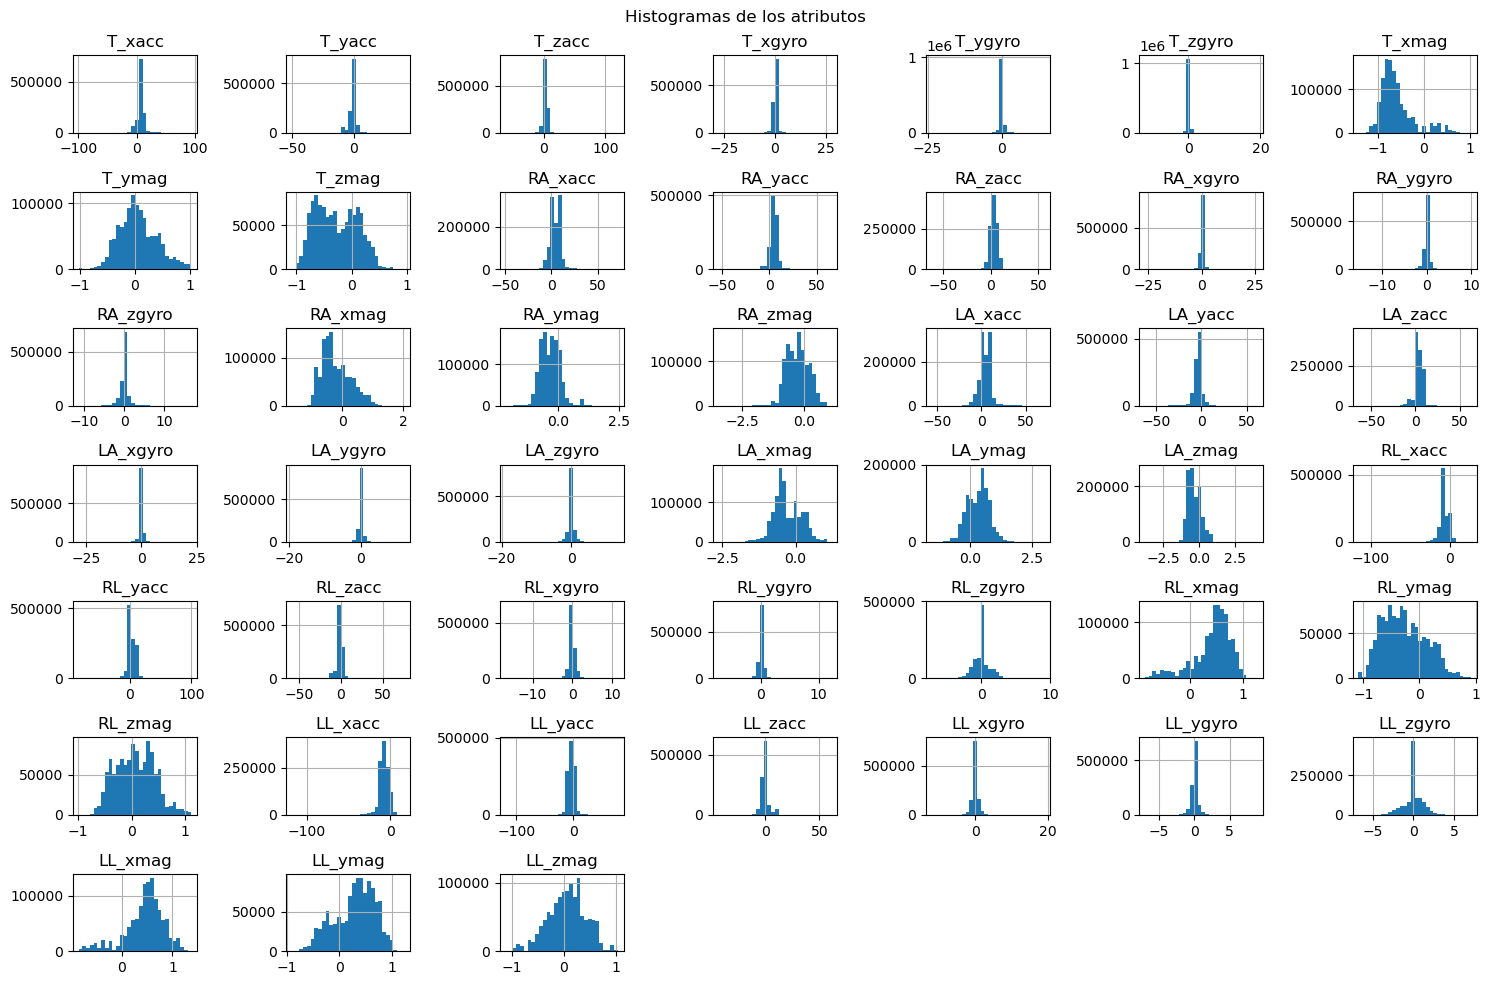

In [32]:
import matplotlib.pyplot as plt

# Crear el histograma
only_sensor_columns.hist(bins=30, figsize=(15, 10))

# Configurar los límites y el título
plt.xlim(-10, 10)
plt.suptitle("Histogramas de los atributos")

# Ajustar el diseño
plt.tight_layout()

# Guardar la imagen en 4K (3840x2160 píxeles, aprox. dpi=300)
plt.savefig("histogramas_4k.png", dpi=300, bbox_inches='tight')

# Mostrar la imagen en pantalla
plt.show()


## 1.9. Genera la gráfica de densidad para la distribución de los atributos de cada base de datos

In [34]:
#only_sensor_columns.plot(kind='density', subplots=True, layout=(10, 6), figsize=(20, 20), sharex=False)


#plt.suptitle("Diagramas de Densidad de los Atributos", fontsize=16)
#plt.tight_layout()
#plt.show()

## 1.10. Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos

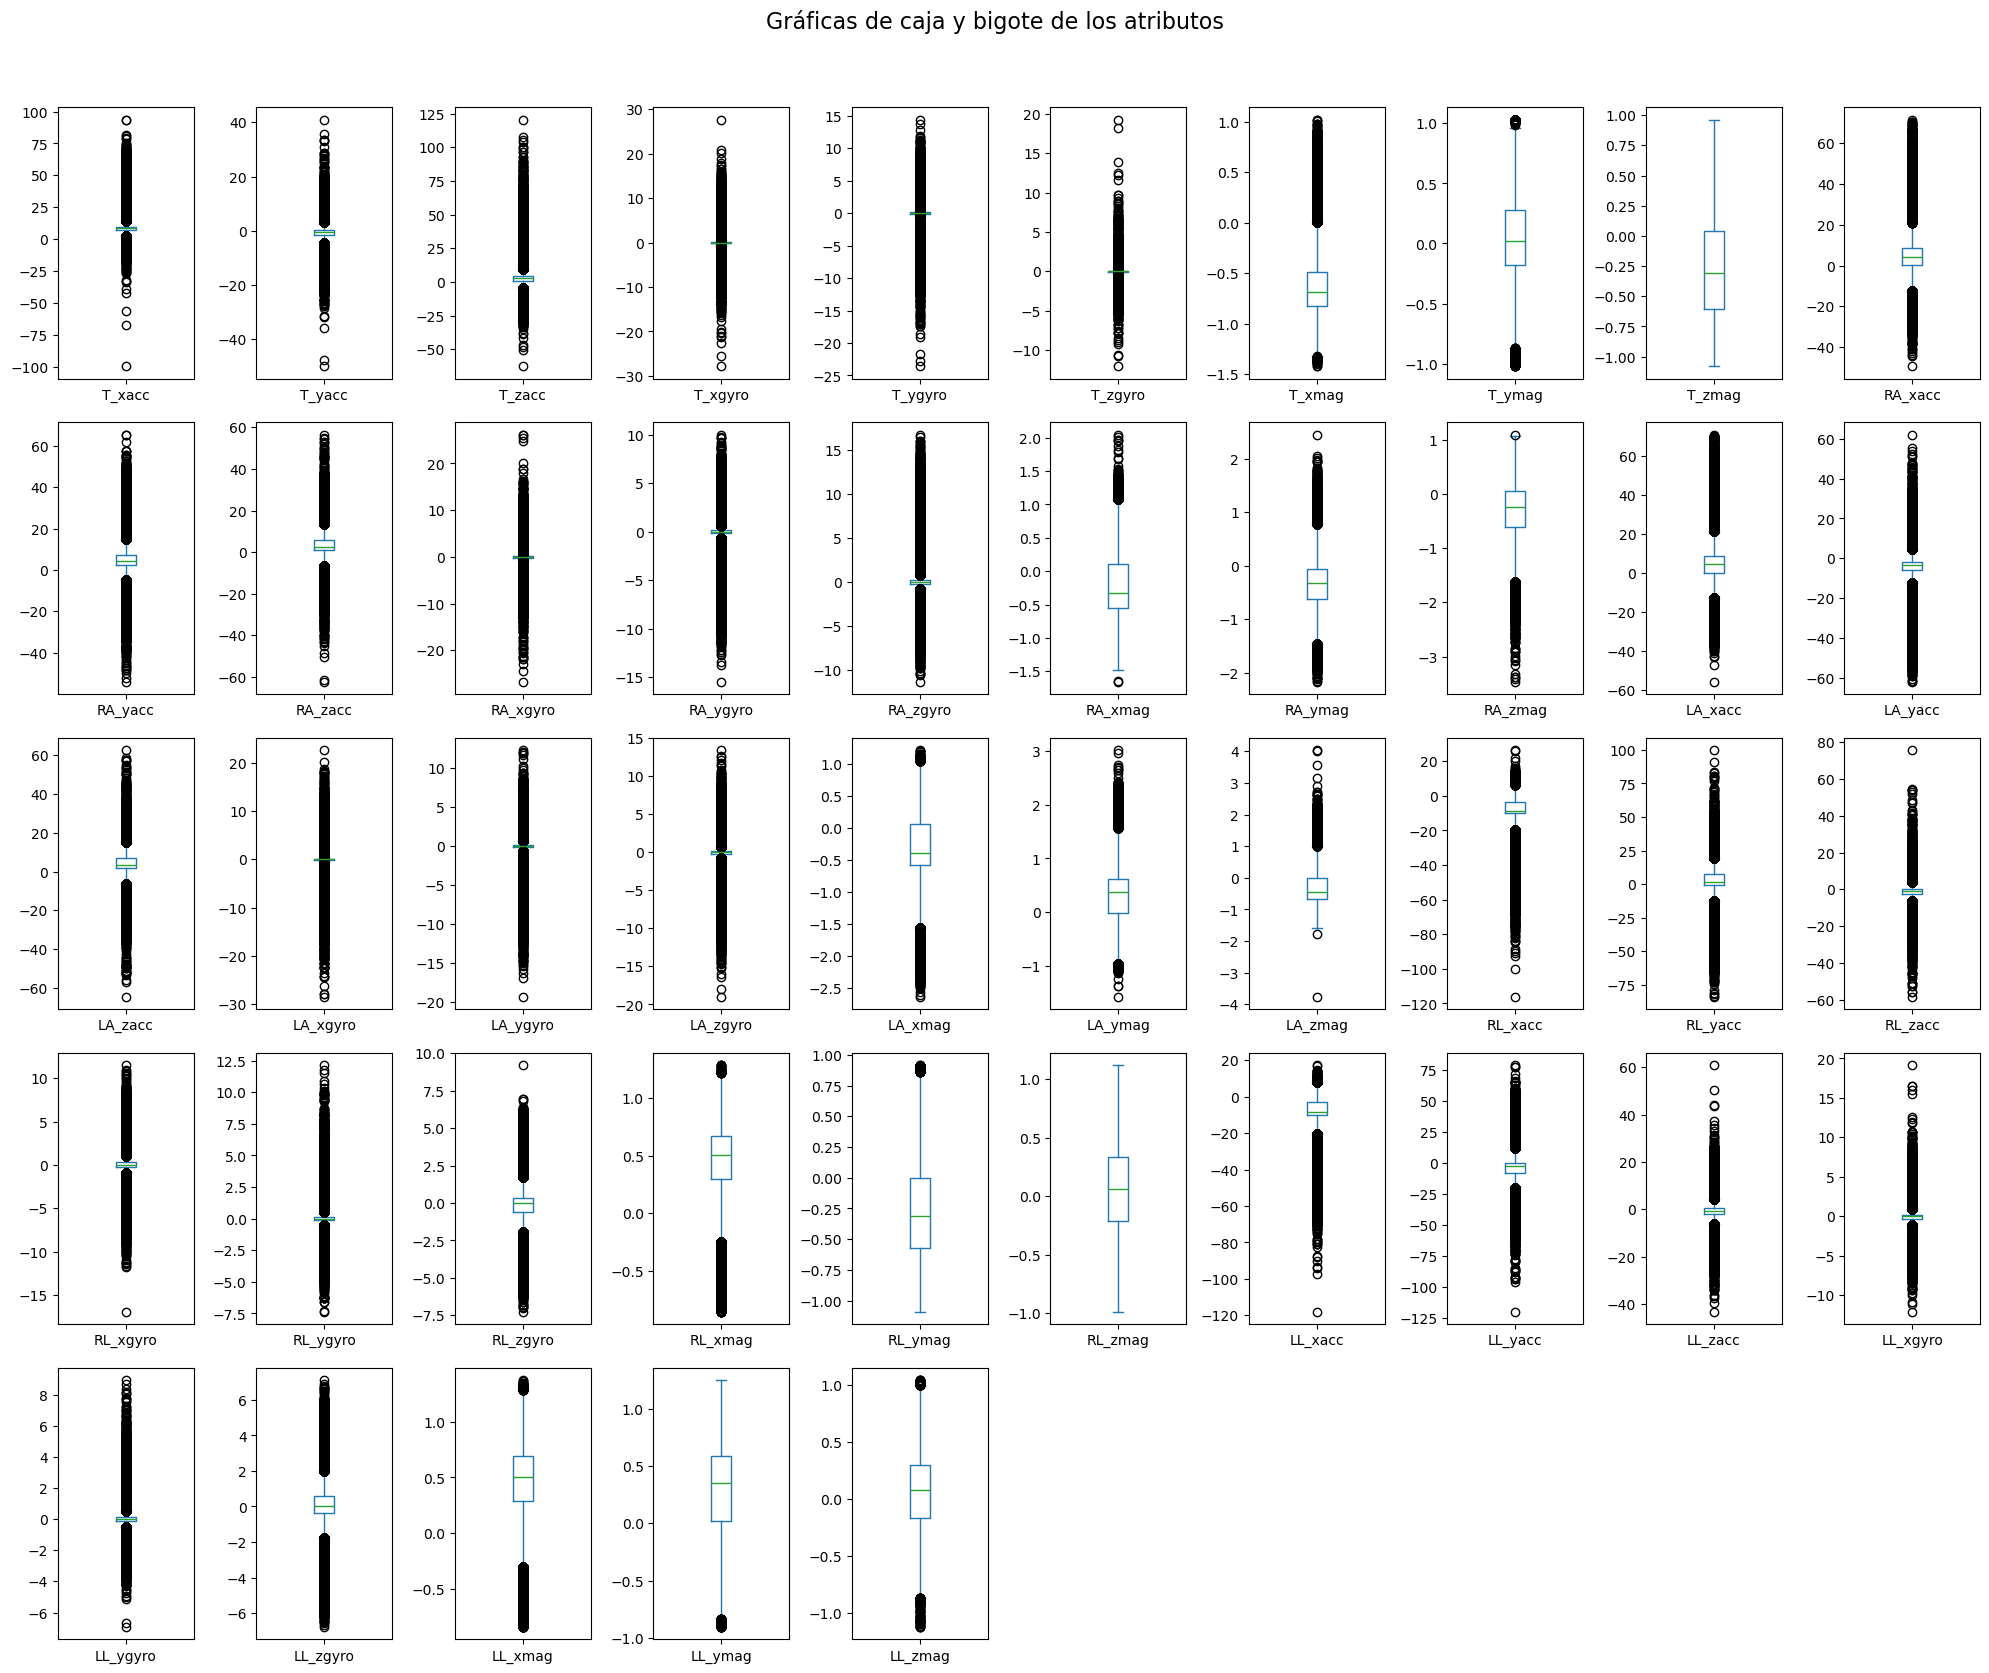

In [36]:
import matplotlib.pyplot as plt

# Crear las gráficas de caja y bigote
only_sensor_columns.plot(kind='box', subplots=True, layout=(6, 10), figsize=(20, 20), sharex=False)

# Configurar el título
plt.suptitle("Gráficas de caja y bigote de los atributos", fontsize=16)

# Ajustar el diseño para que no se sobrepongan los elementos
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar la imagen en alta resolución (por ejemplo, 300 DPI)
plt.savefig("boxplots_4k.png", dpi=300, bbox_inches='tight')

# Mostrar la gráfica en pantalla
plt.show()

## 1.11. Genera la matriz de correlación de los atributos para cada una de las bases de datos

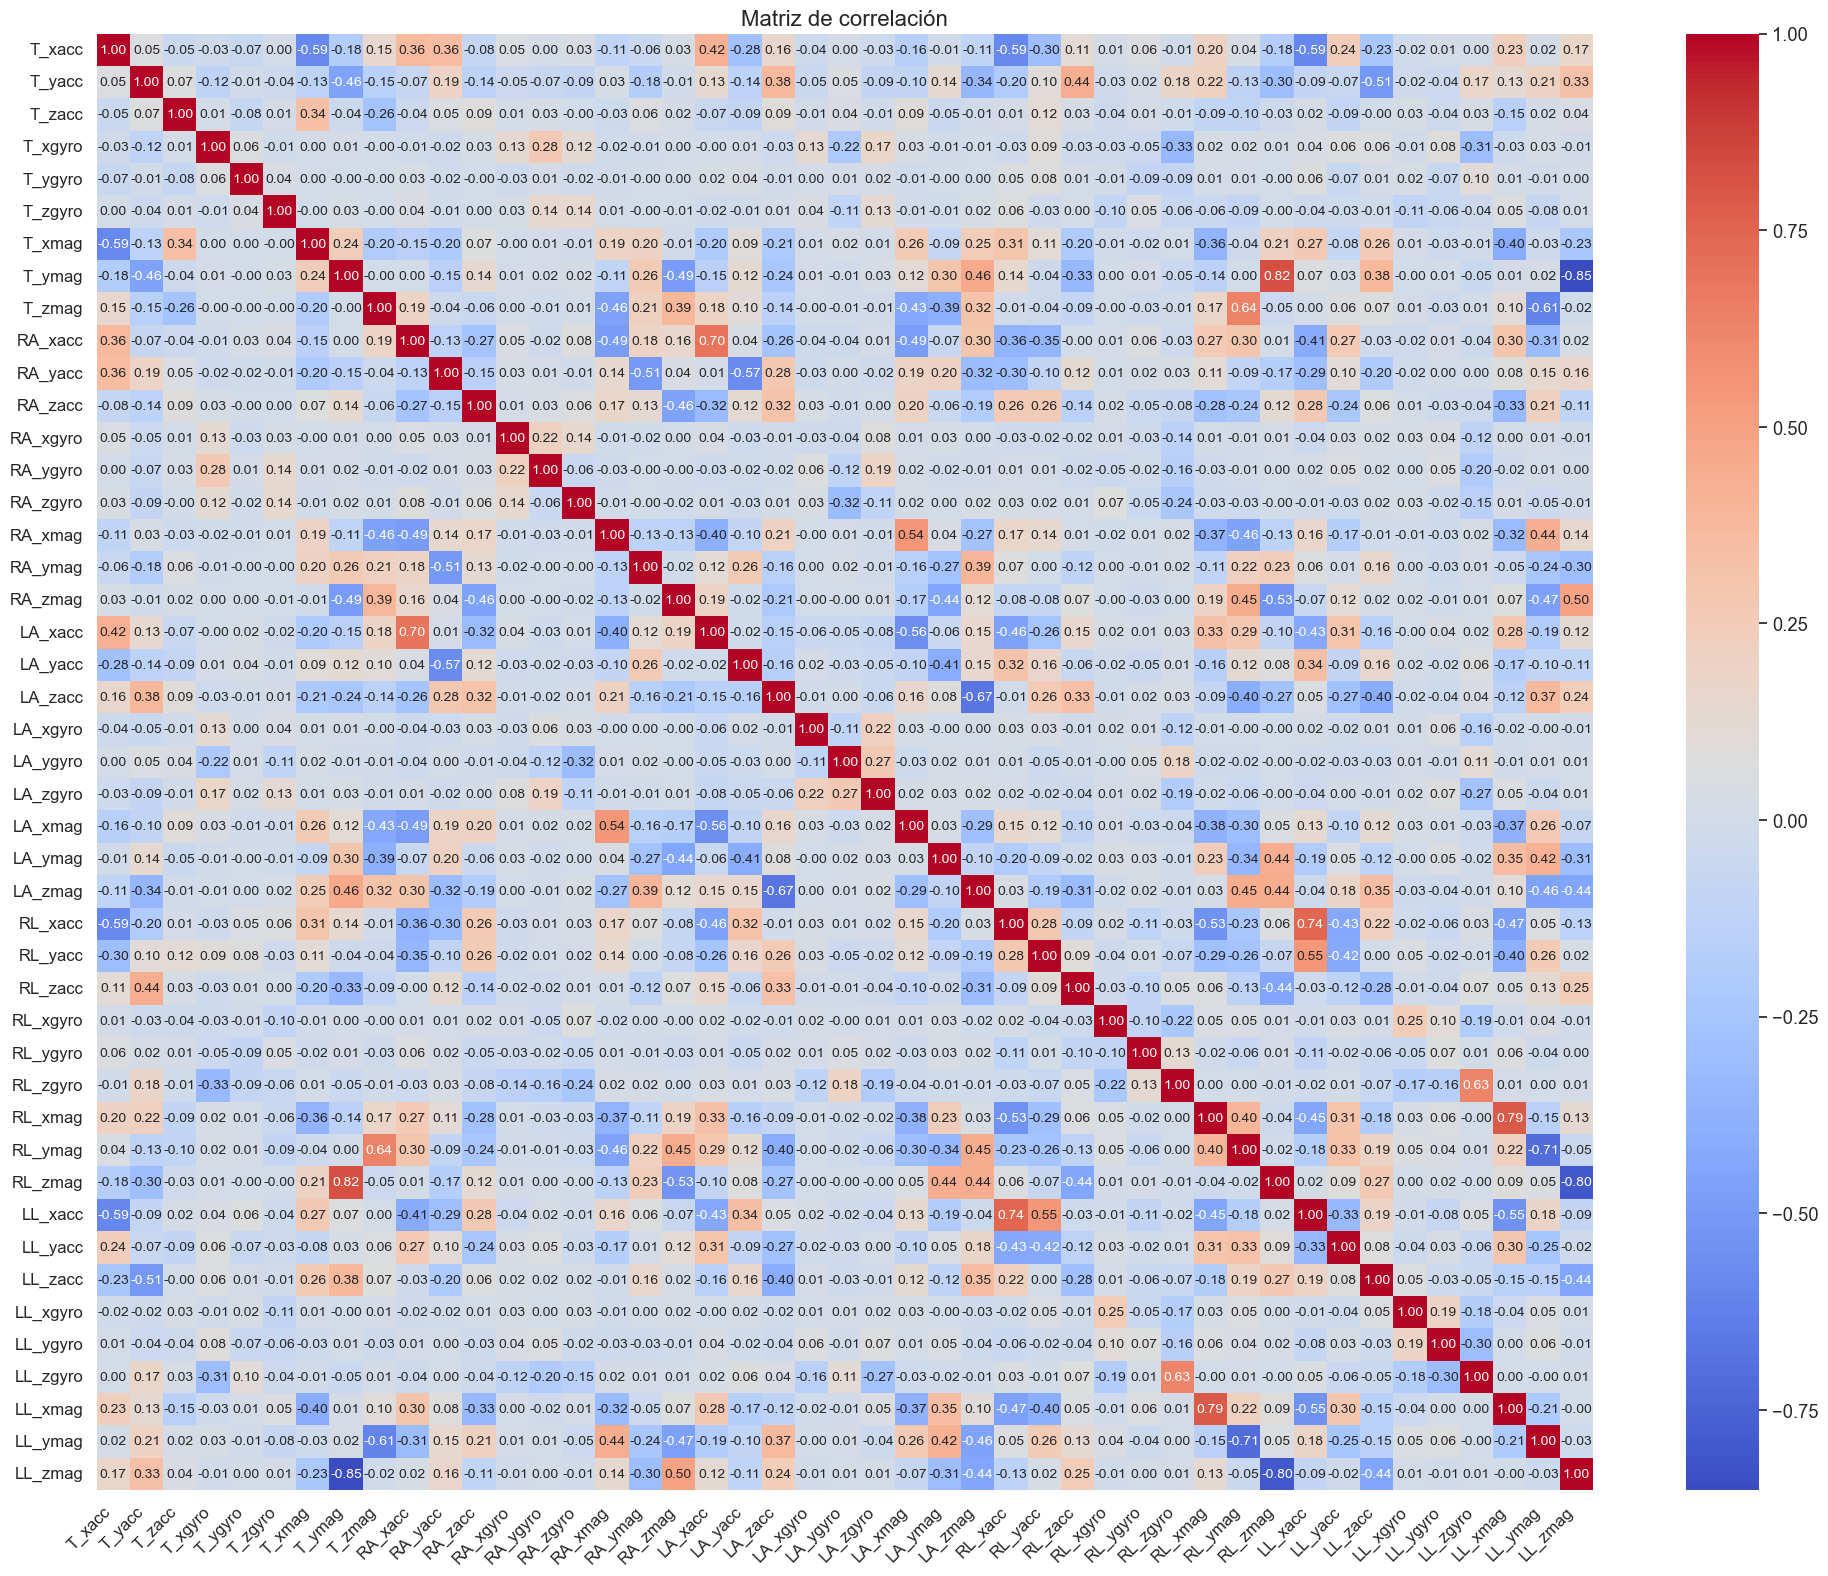

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.2)

plt.figure(figsize=(20, 16))  

sns.heatmap(
    dsa_corr_matrix, 
    annot=True,        # Show numerical values
    fmt=".2f",         
    cmap="coolwarm",
    annot_kws={"size": 10}  # Increase font size for the numbers in cells
)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.title('Matriz de correlación', fontsize=16)

plt.tight_layout()

# plt.savefig("correlation_matrix_pearson_daily.png", dpi=300, bbox_inches="tight")

plt.show()


In [39]:
threshold = 0.8
high_corr_pairs = []

for i in range(len(dsa_corr_matrix.columns)):
    for j in range(i+1, len(dsa_corr_matrix.columns)):
        corr_value = dsa_corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append((dsa_corr_matrix.columns[i], dsa_corr_matrix.columns[j], corr_value))

for col1, col2, corr_value in high_corr_pairs:
    print(f"Las columnas '{col1}' y '{col2}' tienen una correlación de {corr_value:.2f}")


Las columnas 'T_ymag' y 'RL_zmag' tienen una correlación de 0.82
Las columnas 'T_ymag' y 'LL_zmag' tienen una correlación de -0.85


## 1.12. Genera la matriz de dispersión de los atributos para cada base de datos

In [41]:
#from pandas.plotting import scatter_matrix

#scatter_matrix(only_sensor_columns, figsize=(12, 10), diagonal='hist')

#plt.suptitle("Matriz de dispersión de los atributos", fontsize=16)
#plt.show()

## 1.13. Aplica escalamiento, normalización o estandarización

Este proceso se realizará después de la extracción de características en la sección: **2.4. Escalamiento, normalización o estandarización de características**

## 1.14. Tratamiento de datos anómalos

Como se pudo observar en las gráficas de caja y bigotes, el dataset contiene muchos datos anómalos. Estos datos anómalos son valores inusualmente extremos y que se generan a causa de ruido en la medición, al ser externos al fenómeno mismo, queremos eliminarlos para evitar ajustarnos a las mediciones de un ejemplo en partícular y en su lugar ajustarnos al patrón general de los datos. 

Dado que muchos de los sensores están correlacionados, se elige la Mahalanobis Distance como medida de distancia para determinar si un valor está tan alejado de los demás como para ser considerado un outlier. 

Para eliminar outliers, eliminamos los valores que estén muy alejados según su distancia Mahalanobis por cada clase. 

In [48]:
non_sensor_columns = ["activity_label", "person_id", "segment"]
only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

In [49]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt


only_sensor_columns_filtered = only_sensor_columns.apply(lambda col: medfilt(col, kernel_size=3))

dsaa_no_outlier = pd.concat([dsa_df[non_sensor_columns], only_sensor_columns_filtered], axis=1)

# Visualizar el DataFrame final
dsaa_no_outlier

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,RA_yacc,RA_zacc,RA_xgyro,RA_ygyro,RA_zgyro,RA_xmag,RA_ymag,RA_zmag,LA_xacc,LA_yacc,LA_zacc,LA_xgyro,LA_ygyro,LA_zgyro,LA_xmag,LA_ymag,LA_zmag,RL_xacc,RL_yacc,RL_zacc,RL_xgyro,RL_ygyro,RL_zgyro,RL_xmag,RL_ymag,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,-0.068,0.157,0.701,5.601,7.971,0.004,-0.005,-0.001,-0.573,-0.557,-0.212,3.419,-8.342,3.854,-0.005,-0.002,-0.005,-0.648,0.341,0.074,-3.516,9.051,-0.933,0.005,0.003,-0.012,0.730,-0.252,-0.034,-2.807,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,-0.068,0.159,0.701,5.661,7.971,0.013,-0.005,-0.001,-0.573,-0.558,-0.213,3.429,-8.371,3.863,-0.005,-0.008,-0.012,-0.648,0.341,0.074,-3.538,9.066,-0.933,0.005,0.008,-0.012,0.730,-0.252,-0.036,-2.815,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,-0.068,0.159,0.718,5.639,7.971,0.016,-0.005,0.002,-0.574,-0.558,-0.213,3.434,-8.371,3.854,0.000,-0.002,-0.011,-0.648,0.341,0.074,-3.538,9.066,-0.933,0.001,0.008,-0.008,0.731,-0.252,-0.036,-2.815,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,-0.069,0.159,0.716,5.644,7.971,0.016,-0.003,0.002,-0.574,-0.560,-0.214,3.444,-8.371,3.847,0.000,0.004,-0.011,-0.648,0.341,0.074,-3.538,9.066,-0.933,-0.010,0.008,-0.003,0.730,-0.252,-0.036,-2.815,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,-0.070,0.159,0.716,5.644,7.971,0.013,-0.003,0.002,-0.569,-0.560,-0.214,3.444,-8.356,3.847,-0.007,0.004,-0.009,-0.648,0.342,0.075,-3.538,9.059,-0.933,0.001,0.008,-0.003,0.730,-0.252,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,-0.476,-0.013,16.431,15.668,2.397,3.196,0.241,5.856,-0.674,-0.529,-0.102,-12.331,-3.756,6.592,-1.014,-0.785,0.138,0.450,0.657,-0.330,-24.517,-3.180,-10.979,0.986,-0.769,-3.636,0.908,-0.070,-0.068,-10.752,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,-0.476,-0.013,7.016,20.931,-0.253,3.746,0.259,4.173,-0.775,-0.393,-0.047,-4.380,-4.216,6.548,0.320,-0.619,-0.339,0.437,0.657,-0.330,-24.517,15.918,1.266,0.986,-0.606,-3.636,0.908,0.129,-0.063,-5.184,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,-0.479,-0.012,-4.554,21.249,2.397,3.196,0.221,2.469,-0.820,-0.298,0.002,3.017,-4.216,5.155,1.913,-0.213,-0.943,0.416,0.651,-0.375,-11.025,22.042,1.266,-1.311,-0.606,-1.423,0.817,0.149,-0.063,-3.648,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,-0.482,-0.011,-6.801,21.249,5.241,1.696,0.048,-0.388,-0.820,-0.298,0.040,3.017,-4.216,5.155,3.439,0.990,-2.388,0.377,0.632,-0.434,-0.563,22.042,-1.651,-1.364,0.264,0.845,0.817,0.160,-0.195,-1.035,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489


In [50]:
dsaa_no_outlier.describe()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,RA_yacc,RA_zacc,RA_xgyro,RA_ygyro,RA_zgyro,RA_xmag,RA_ymag,RA_zmag,LA_xacc,LA_yacc,LA_zacc,LA_xgyro,LA_ygyro,LA_zgyro,LA_xmag,LA_ymag,LA_zmag,RL_xacc,RL_yacc,RL_zacc,RL_xgyro,RL_ygyro,RL_zgyro,RL_xmag,RL_ymag,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
count,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000
mean,7.670,-0.803,2.699,0.002,0.024,-0.003,-0.598,0.062,-0.273,4.220,4.911,3.115,0.015,-0.021,-0.004,-0.211,-0.326,-0.261,4.230,-3.886,3.812,-0.017,-0.022,0.004,-0.278,0.323,-0.344,-7.258,2.676,-1.527,0.019,0.026,-0.008,0.428,-0.270,0.069,-7.215,-3.186,-0.534,-0.018,0.024,0.001,0.458,0.296,0.065
std,5.151,2.489,2.997,0.643,0.511,0.261,0.356,0.340,0.373,5.572,4.296,3.734,0.761,0.729,0.994,0.463,0.383,0.437,5.748,4.122,4.263,0.821,0.774,0.952,0.468,0.438,0.448,5.287,4.985,2.693,0.699,0.380,1.107,0.364,0.383,0.361,5.266,4.812,3.054,0.705,0.402,1.120,0.380,0.384,0.357
min,-66.980,-26.959,-21.403,-13.829,-16.179,-6.851,-1.415,-1.016,-1.062,-37.793,-37.467,-42.666,-14.839,-12.209,-9.821,-1.480,-2.123,-3.409,-38.778,-49.282,-48.246,-18.684,-14.865,-16.013,-2.558,-1.377,-1.587,-50.065,-31.623,-34.861,-9.513,-4.777,-5.167,-0.855,-1.088,-0.986,-49.937,-31.213,-24.213,-8.155,-4.278,-5.702,-0.844,-0.901,-1.125
25%,6.952,-1.466,0.905,-0.149,-0.091,-0.092,-0.825,-0.179,-0.602,0.101,2.566,0.808,-0.123,-0.161,-0.197,-0.550,-0.622,-0.613,0.144,-6.008,1.649,-0.138,-0.165,-0.168,-0.586,-0.011,-0.680,-9.825,-0.299,-2.351,-0.170,-0.096,-0.561,0.302,-0.574,-0.215,-9.802,-7.159,-2.046,-0.288,-0.110,-0.327,0.293,0.020,-0.171
50%,8.844,-0.388,2.664,0.001,0.018,-0.003,-0.690,0.023,-0.309,4.129,4.601,2.643,0.008,-0.004,-0.001,-0.331,-0.329,-0.246,4.594,-3.412,3.479,-0.002,-0.002,-0.006,-0.387,0.380,-0.451,-8.916,1.571,-1.170,0.001,0.009,-0.008,0.507,-0.308,0.062,-8.680,-2.201,-0.823,-0.004,0.000,-0.001,0.508,0.352,0.081
75%,9.673,0.387,4.309,0.155,0.121,0.084,-0.493,0.282,0.041,8.498,7.483,5.846,0.150,0.139,0.178,0.104,-0.062,0.059,8.751,-1.702,7.021,0.127,0.146,0.163,0.064,0.622,-0.005,-3.324,6.875,-0.135,0.278,0.138,0.313,0.669,0.001,0.336,-2.712,0.000,0.225,0.166,0.132,0.555,0.690,0.585,0.298
max,50.026,13.884,40.889,20.229,11.900,12.470,1.008,1.030,0.921,69.217,55.374,33.197,18.777,8.367,16.078,2.009,1.964,1.060,65.611,34.427,34.725,15.719,11.565,12.565,1.192,2.732,3.994,13.370,38.176,21.066,8.704,4.607,5.119,1.288,0.917,1.115,11.182,28.508,19.674,9.798,8.004,5.777,1.371,1.242,1.037


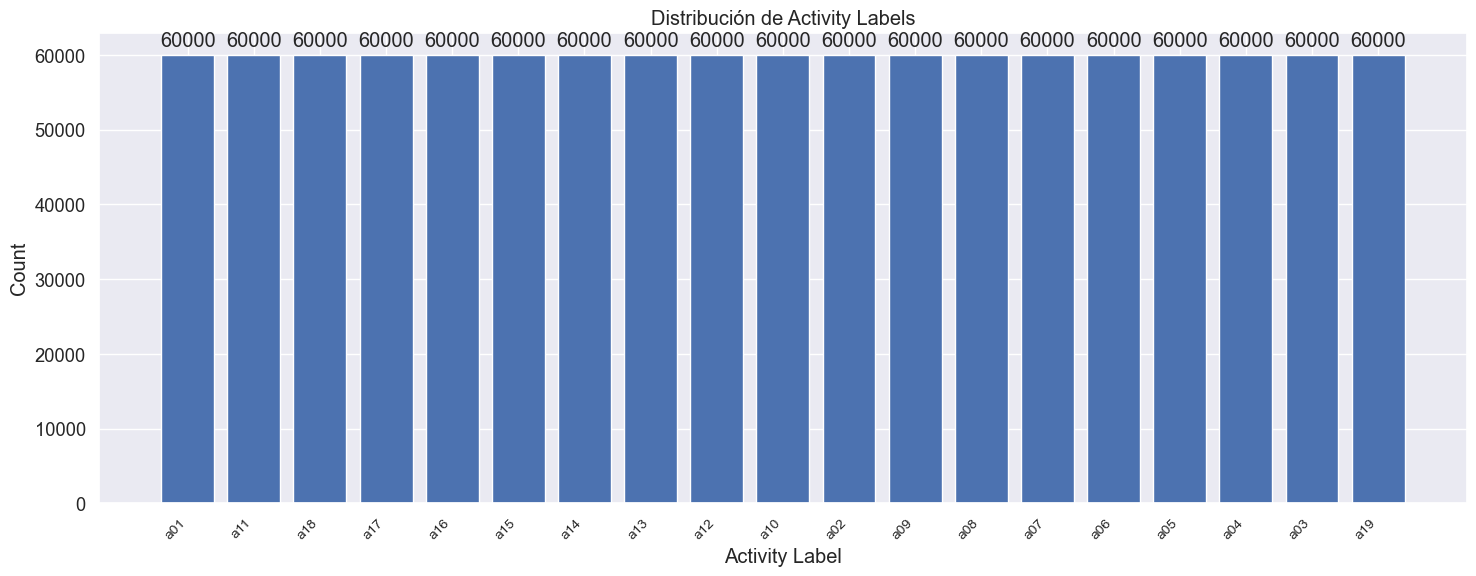

In [51]:
import matplotlib.pyplot as plt

dsa_class_distribution = dsaa_no_outlier['activity_label'].value_counts()

distr = dsa_class_distribution

plt.figure(figsize=(15, 6))
bars = plt.bar(distr.index, distr.values)

plt.xlabel('Activity Label')
plt.ylabel('Count')
plt.title('Distribución de Activity Labels')

# Agregar la cantidad exacta en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height * 1.01, f'{int(height)}', ha='center', va='bottom')

# Rotar etiquetas del eje X y ajustar el tamaño de la fuente
plt.xticks(rotation=45, ha='right', fontsize=10)

# Ajustar los márgenes para que las etiquetas no se recorten
plt.subplots_adjust(bottom=0.25)

plt.tight_layout()
plt.show()

In [52]:
dsaa_no_outlier.dtypes

activity_label     object
person_id          object
segment            object
T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag     

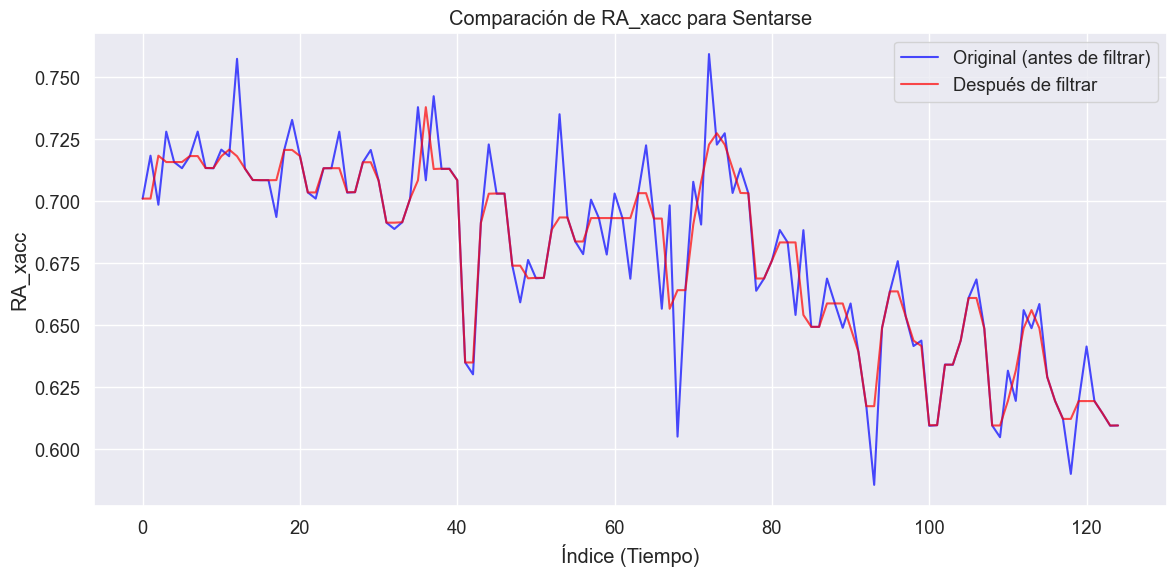

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a01p1s01.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para Sentarse')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


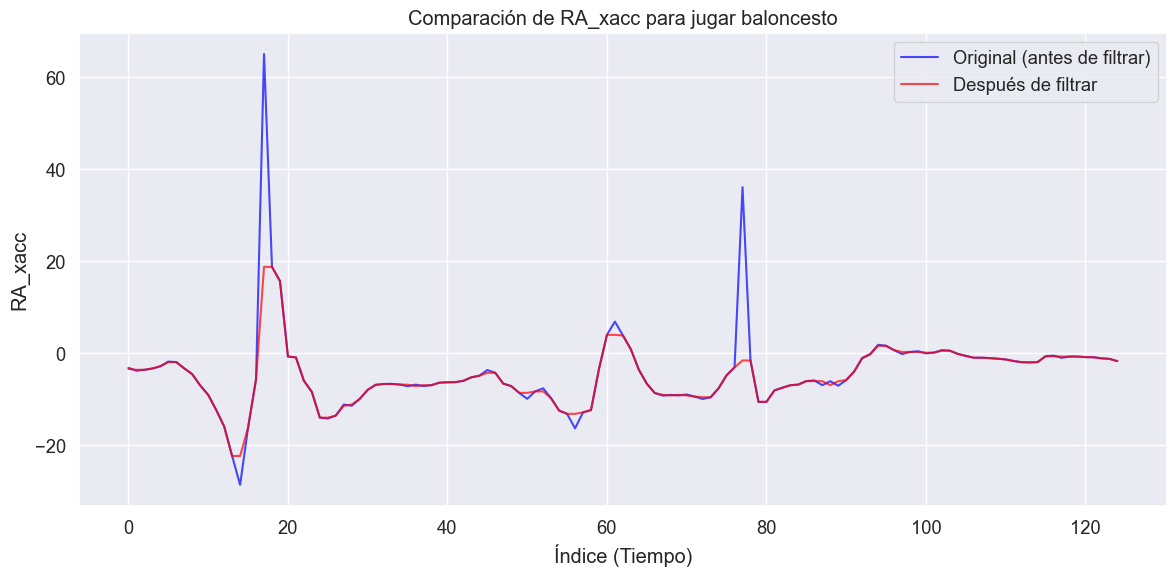

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a19p1s03.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para jugar baloncesto')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Intentamos por segmentos de 5s en lugar de por clase:

In [56]:
def segmentar_por_3s(df, window_size=75):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activity_label', 'person_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)

df_unsegmented = dsaa_no_outlier

dsaa_no_outlier3 = segmentar_por_3s(df_unsegmented)
dsaa_no_outlier3

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,RA_yacc,RA_zacc,RA_xgyro,RA_ygyro,RA_zgyro,RA_xmag,RA_ymag,RA_zmag,LA_xacc,LA_yacc,LA_zacc,LA_xgyro,LA_ygyro,LA_zgyro,LA_xmag,LA_ymag,LA_zmag,RL_xacc,RL_yacc,RL_zacc,RL_xgyro,RL_ygyro,RL_zgyro,RL_xmag,RL_ymag,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,segment_index,segment_3s
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,-0.068,0.157,0.701,5.601,7.971,0.004,-0.005,-0.001,-0.573,-0.557,-0.212,3.419,-8.342,3.854,-0.005,-0.002,-0.005,-0.648,0.341,0.074,-3.516,9.051,-0.933,0.005,0.003,-0.012,0.730,-0.252,-0.034,-2.807,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058,0,a01p10
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,-0.068,0.159,0.701,5.661,7.971,0.013,-0.005,-0.001,-0.573,-0.558,-0.213,3.429,-8.371,3.863,-0.005,-0.008,-0.012,-0.648,0.341,0.074,-3.538,9.066,-0.933,0.005,0.008,-0.012,0.730,-0.252,-0.036,-2.815,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058,0,a01p10
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,-0.068,0.159,0.718,5.639,7.971,0.016,-0.005,0.002,-0.574,-0.558,-0.213,3.434,-8.371,3.854,0.000,-0.002,-0.011,-0.648,0.341,0.074,-3.538,9.066,-0.933,0.001,0.008,-0.008,0.731,-0.252,-0.036,-2.815,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058,0,a01p10
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,-0.069,0.159,0.716,5.644,7.971,0.016,-0.003,0.002,-0.574,-0.560,-0.214,3.444,-8.371,3.847,0.000,0.004,-0.011,-0.648,0.341,0.074,-3.538,9.066,-0.933,-0.010,0.008,-0.003,0.730,-0.252,-0.036,-2.815,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058,0,a01p10
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,-0.070,0.159,0.716,5.644,7.971,0.013,-0.003,0.002,-0.569,-0.560,-0.214,3.444,-8.356,3.847,-0.007,0.004,-0.009,-0.648,0.342,0.075,-3.538,9.059,-0.933,0.001,0.008,-0.003,0.730,-0.252,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058,0,a01p10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,-0.476,-0.013,16.431,15.668,2.397,3.196,0.241,5.856,-0.674,-0.529,-0.102,-12.331,-3.756,6.592,-1.014,-0.785,0.138,0.450,0.657,-0.330,-24.517,-3.180,-10.979,0.986,-0.769,-3.636,0.908,-0.070,-0.068,-10.752,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518,99,a19p899
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,-0.476,-0.013,7.016,20.931,-0.253,3.746,0.259,4.173,-0.775,-0.393,-0.047,-4.380,-4.216,6.548,0.320,-0.619,-0.339,0.437,0.657,-0.330,-24.517,15.918,1.266,0.986,-0.606,-3.636,0.908,0.129,-0.063,-5.184,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504,99,a19p899
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,-0.479,-0.012,-4.554,21.249,2.397,3.196,0.221,2.469,-0.820,-0.298,0.002,3.017,-4.216,5.155,1.913,-0.213,-0.943,0.416,0.651,-0.375,-11.025,22.042,1.266,-1.311,-0.606,-1.423,0.817,0.149,-0.063,-3.648,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489,99,a19p899
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,-0.482,-0.011,-6.801,21.249,5.241,1.696,0.048,-0.388,-0.820,-0.298,0.040,3.017,-4.216,5.155,3.439,0.990,-2.388,0.377,0.632,-0.434,-0.563,22.042,-1.651,-1.364,0.264,0.845,0.817,0.160,-0.195,-1.035,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489,99,a19p899


In [57]:
non_sensor_columns_3s = ["activity_label", "person_id", "segment", "segment_index", "segment_3s"]
only_sensor_columns_3s = dsaa_no_outlier3.drop(non_sensor_columns_3s, axis="columns")

In [58]:
only_sensor_columns_3s.dtypes

T_xacc      float64
T_yacc      float64
T_zacc      float64
T_xgyro     float64
T_ygyro     float64
T_zgyro     float64
T_xmag      float64
T_ymag      float64
T_zmag      float64
RA_xacc     float64
RA_yacc     float64
RA_zacc     float64
RA_xgyro    float64
RA_ygyro    float64
RA_zgyro    float64
RA_xmag     float64
RA_ymag     float64
RA_zmag     float64
LA_xacc     float64
LA_yacc     float64
LA_zacc     float64
LA_xgyro    float64
LA_ygyro    float64
LA_zgyro    float64
LA_xmag     float64
LA_ymag     float64
LA_zmag     float64
RL_xacc     float64
RL_yacc     float64
RL_zacc     float64
RL_xgyro    float64
RL_ygyro    float64
RL_zgyro    float64
RL_xmag     float64
RL_ymag     float64
RL_zmag     float64
LL_xacc     float64
LL_yacc     float64
LL_zacc     float64
LL_xgyro    float64
LL_ygyro    float64
LL_zgyro    float64
LL_xmag     float64
LL_ymag     float64
LL_zmag     float64
dtype: object

In [59]:
dsaa_no_outlier3.columns

Index(['activity_label', 'person_id', 'segment', 'T_xacc', 'T_yacc', 'T_zacc',
       'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
       'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro',
       'RA_xmag', 'RA_ymag', 'RA_zmag', 'LA_xacc', 'LA_yacc', 'LA_zacc',
       'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
       'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro',
       'RL_xmag', 'RL_ymag', 'RL_zmag', 'LL_xacc', 'LL_yacc', 'LL_zacc',
       'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag',
       'segment_index', 'segment_3s'],
      dtype='object')

# 2 Segunda entrega: extracción de características

## 2.1. Segmentación por ventanas de tiempo

El dataset viene con las ventanas de tiempo pre-armadas como 5 segundos. Pero nosotros queremos reducirlo hasta 3 segundos. Para esto tendremos que volver a segmentar las mediciones de las actividades. 

Los sensores están a 25Hz y el dataset original los tiene en grupos de 5s, lo que significa que cada grupo de 5s tiene un total de: (5s)(25Hz) = 125 mediciones. Dado que tenemos 60 segmentos de 5s en nuestro dataset original, la cantidad total de mediciones que tenemos para una misma actividad ejecutada por una misma persona son: (60 segmentos)(125 mediciones/segmento) = 7500 mediciones en total.

Si queremos pasarlo a 3 segundos, tendremos ventanas de: (3s)(25Hz) = 75 mediciones. La cantidad total de segmentos que tendremos de una misma actividad ejectuada por una misma persona serán de: (7500 mediciones) / (75 mediciones por segmento) = 100 segmentos.

Nótese que las mediciones encajan perfectamente en las ventanas de tiempo.

Observamos que cada actividad ejecutada por cada persona tiene exactamente 100 segmentos, por lo que se realizaó de manera correcta la segmnetación.

In [67]:
dsaa_no_outlier3.groupby(['activity_label', 'person_id'])['segment_3s'].nunique()

activity_label  person_id
a01             p1           100
                p2           100
                p3           100
                p4           100
                p5           100
                            ... 
a19             p4           100
                p5           100
                p6           100
                p7           100
                p8           100
Name: segment_3s, Length: 152, dtype: int64

## 2.2. Extracción de características

In [69]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

Ahora generamos el dataset con las features de cada ejemplo y sus labels.

In [71]:
import numpy as np
import pandas as pd

df_to_extract_features = dsaa_no_outlier3

numeric_features_list = []
labels = []

for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Torso
    T_features = InertialSensor(group.T_xacc, group.T_yacc, group.T_zacc).extract_features()
    T_gyro_features = InertialSensor(group.T_xgyro, group.T_ygyro, group.T_zgyro).extract_features()
    T_mag_features = InertialSensor(group.T_xmag, group.T_ymag, group.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(group.RA_xacc, group.RA_yacc, group.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(group.RA_xgyro, group.RA_ygyro, group.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(group.RA_xmag, group.RA_ymag, group.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(group.LA_xacc, group.LA_yacc, group.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(group.LA_xgyro, group.LA_ygyro, group.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(group.LA_xmag, group.LA_ymag, group.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(group.RL_xacc, group.RL_yacc, group.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(group.RL_xgyro, group.RL_ygyro, group.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(group.RL_xmag, group.RL_ymag, group.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(group.LL_xacc, group.LL_yacc, group.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(group.LL_xgyro, group.LL_ygyro, group.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(group.LL_xmag, group.LL_ymag, group.LL_zmag).extract_features()
    
    # Combine all feature sets into one row and convert numeric values to float
    feature_vector = np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activity_label"].iloc[0])

# Generate feature column names
sensor_locations = ["T", "RA", "LA", "RL", "LL"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Concatenate numeric features and labels
examples_db = pd.concat([df_numeric, df_labels], axis=1)

# Optionally, check the data types to confirm
examples_db

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,T_acc_corr_xz,T_acc_corr_yz,T_acc_mean_mag,T_acc_std_mag,T_acc_auc,T_acc_mean_diff,T_gyro_mean_x,T_gyro_mean_y,T_gyro_mean_z,T_gyro_std_x,T_gyro_std_y,T_gyro_std_z,T_gyro_max_x,T_gyro_max_y,T_gyro_max_z,T_gyro_corr_xy,T_gyro_corr_xz,T_gyro_corr_yz,T_gyro_mean_mag,T_gyro_std_mag,T_gyro_auc,T_gyro_mean_diff,T_mag_mean_x,T_mag_mean_y,T_mag_mean_z,T_mag_std_x,T_mag_std_y,T_mag_std_z,T_mag_max_x,T_mag_max_y,T_mag_max_z,T_mag_corr_xy,T_mag_corr_xz,T_mag_corr_yz,T_mag_mean_mag,T_mag_std_mag,T_mag_auc,T_mag_mean_diff,RA_acc_mean_x,RA_acc_mean_y,RA_acc_mean_z,RA_acc_std_x,RA_acc_std_y,RA_acc_std_z,RA_acc_max_x,RA_acc_max_y,RA_acc_max_z,RA_acc_corr_xy,RA_acc_corr_xz,RA_acc_corr_yz,RA_acc_mean_mag,RA_acc_std_mag,RA_acc_auc,RA_acc_mean_diff,RA_gyro_mean_x,RA_gyro_mean_y,RA_gyro_mean_z,RA_gyro_std_x,RA_gyro_std_y,RA_gyro_std_z,RA_gyro_max_x,RA_gyro_max_y,RA_gyro_max_z,RA_gyro_corr_xy,RA_gyro_corr_xz,RA_gyro_corr_yz,RA_gyro_mean_mag,RA_gyro_std_mag,RA_gyro_auc,RA_gyro_mean_diff,RA_mag_mean_x,RA_mag_mean_y,RA_mag_mean_z,RA_mag_std_x,RA_mag_std_y,RA_mag_std_z,RA_mag_max_x,RA_mag_max_y,RA_mag_max_z,RA_mag_corr_xy,RA_mag_corr_xz,RA_mag_corr_yz,RA_mag_mean_mag,RA_mag_std_mag,RA_mag_auc,RA_mag_mean_diff,LA_acc_mean_x,LA_acc_mean_y,LA_acc_mean_z,LA_acc_std_x,LA_acc_std_y,LA_acc_std_z,LA_acc_max_x,LA_acc_max_y,LA_acc_max_z,LA_acc_corr_xy,LA_acc_corr_xz,LA_acc_corr_yz,LA_acc_mean_mag,LA_acc_std_mag,LA_acc_auc,LA_acc_mean_diff,LA_gyro_mean_x,LA_gyro_mean_y,LA_gyro_mean_z,LA_gyro_std_x,LA_gyro_std_y,LA_gyro_std_z,LA_gyro_max_x,LA_gyro_max_y,LA_gyro_max_z,LA_gyro_corr_xy,LA_gyro_corr_xz,LA_gyro_corr_yz,LA_gyro_mean_mag,LA_gyro_std_mag,LA_gyro_auc,LA_gyro_mean_diff,LA_mag_mean_x,LA_mag_mean_y,LA_mag_mean_z,LA_mag_std_x,LA_mag_std_y,LA_mag_std_z,LA_mag_max_x,LA_mag_max_y,LA_mag_max_z,LA_mag_corr_xy,LA_mag_corr_xz,LA_mag_corr_yz,LA_mag_mean_mag,LA_mag_std_mag,LA_mag_auc,LA_mag_mean_diff,RL_acc_mean_x,RL_acc_mean_y,RL_acc_mean_z,RL_acc_std_x,RL_acc_std_y,RL_acc_std_z,RL_acc_max_x,RL_acc_max_y,RL_acc_max_z,RL_acc_corr_xy,RL_acc_corr_xz,RL_acc_corr_yz,RL_acc_mean_mag,RL_acc_std_mag,RL_acc_auc,RL_acc_mean_diff,RL_gyro_mean_x,RL_gyro_mean_y,RL_gyro_mean_z,RL_gyro_std_x,RL_gyro_std_y,RL_gyro_std_z,RL_gyro_max_x,RL_gyro_max_y,RL_gyro_max_z,RL_gyro_corr_xy,RL_gyro_corr_xz,RL_gyro_corr_yz,RL_gyro_mean_mag,RL_gyro_std_mag,RL_gyro_auc,RL_gyro_mean_diff,RL_mag_mean_x,RL_mag_mean_y,RL_mag_mean_z,RL_mag_std_x,RL_mag_std_y,RL_mag_std_z,RL_mag_max_x,RL_mag_max_y,RL_mag_max_z,RL_mag_corr_xy,RL_mag_corr_xz,RL_mag_corr_yz,RL_mag_mean_mag,RL_mag_std_mag,RL_mag_auc,RL_mag_mean_diff,LL_acc_mean_x,LL_acc_mean_y,LL_acc_mean_z,LL_acc_std_x,LL_acc_std_y,LL_acc_std_z,LL_acc_max_x,LL_acc_max_y,LL_acc_max_z,LL_acc_corr_xy,LL_acc_corr_xz,LL_acc_corr_yz,LL_acc_mean_mag,LL_acc_std_mag,LL_acc_auc,LL_acc_mean_diff,LL_gyro_mean_x,LL_gyro_mean_y,LL_gyro_mean_z,LL_gyro_std_x,LL_gyro_std_y,LL_gyro_std_z,LL_gyro_max_x,LL_gyro_max_y,LL_gyro_max_z,LL_gyro_corr_xy,LL_gyro_corr_xz,LL_gyro_corr_yz,LL_gyro_mean_mag,LL_gyro_std_mag,LL_gyro_auc,LL_gyro_mean_diff,LL_mag_mean_x,LL_mag_mean_y,LL_mag_mean_z,LL_mag_std_x,LL_mag_std_y,LL_mag_std_z,LL_mag_max_x,LL_mag_max_y,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,-0.951,0.901,9.815,0.035,736.097,0.000,0.009,0.038,-0.003,0.012,0.028,0.006,0.040,0.118,0.014,0.591,-0.123,-0.417,0.043,0.025,3.203,0.000,-0.790,-0.068,0.141,0.003,0.001,0.017,-0.786,-0.065,0.159,-0.890,0.990,-0.897,0.805,0.000,60.398,-0.000,0.700,5.676,7.950,0.020,0.033,0.023,0.738,5.729,7.981,-0.448,0.220,-0.775,9.793,0.012,734.508,0.000,0.012,-0.002,-0.002,0.007,0.006,0.005,0.028,0.013,0.010,0.117,0.008,-0.155,0.015,0.006,1.102,0.000,-0.570,-0.560,-0.212,0.003,0.002,0.002,-0.564,-0.557,-0.207,-0.132,0.777,-0.086,0.827,0.002,62

In [72]:
examples_db.dtypes

T_acc_mean_x        float64
T_acc_mean_y        float64
T_acc_mean_z        float64
T_acc_std_x         float64
T_acc_std_y         float64
                     ...   
LL_mag_mean_mag     float64
LL_mag_std_mag      float64
LL_mag_auc          float64
LL_mag_mean_diff    float64
activity             object
Length: 241, dtype: object

Esperamos tener 15,200 filas, esto porque los ejemplos son:

- (18 personas) (9 actividades) (100 ejemplos usando ventanas de 3s) = 15,200 ejemplos

Esperamos tener 240 columnas de características + 1 columna de la etiqueta de la actividad

- (16 características por sensor) (15 sensores) + 1 label = 240 features + 1 label = 241 columnas

In [74]:
examples_db.shape

(15200, 241)

Histograma de las características

In [76]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Drop 'activity' column if it exists, keeping only numeric columns
examples_db_numeric = examples_db.drop(columns=["activity"], errors="ignore")

# Number of numeric columns
num_features = len(examples_db_numeric.columns)

# We'll create an n x n grid, where n is the ceiling of the square root of the number of features
n = math.ceil(math.sqrt(num_features))

# Increase the figure size depending on how many features you have
figsize = (6 * n, 4 * n)

# Create the histograms in a grid layout
axes = examples_db_numeric.hist(
    bins=10,
    figsize=figsize,
    layout=(n, n),     # n rows, n columns
    sharex=False,
    sharey=False
)

# If axes is a 2D numpy array, flatten it so we can iterate easily
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# Adjust each subplot for better readability
for ax in axes:
    # Rotate the x-axis labels
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    # Optionally reduce title font size
    ax.set_title(ax.get_title(), fontsize=9)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.4, hspace=0.4)

# Add a main title
plt.suptitle("Histogramas de las características", fontsize=16, y=1.02)

# Use tight_layout with a rect so the suptitle doesn't overlap subplots
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Usamos Group KFold para mantener los segmentos de ventanas de tiempo. Si no se usara las mediciones se mezclarían. Nótese que no es necesario utilizar Stratified debido a que las calses ya están balanceadas. 

## 2.3. Escalamiento, normalización o estandarización de características

In [79]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

Se utiliza **StandardScaler**. Pero es importante aplicarlo por separado en el set de entrenamiento y en el de prueba para evitar data leakage. Para tener mayor certeza en el desempeño del clasificador, se utilizará Cross Validation. Por todo esto es importante realizar el Cross Validation antes de aplicar la transformación.

## 2.4. Train/test split: cross validation

Usamos Group KFold para mantener los segmentos de ventanas de tiempo. Si no se usara las mediciones se mezclarían. Nótese que no es necesario utilizar Stratified debido a que las calses ya están balanceadas. 

In [83]:
from imblearn.pipeline import make_pipeline

Solo para probar que sí sirve, usamos un NB Gaussiano. Elejimos el NB gaussiano ya que es una forma rápida de hacer un modelo sencillo y rápido que no depende de la escala. Esto porque no puedo garantizar que las esclas estén bien después de usar MinMax porque no se probaron supuestos. 

In [85]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [86]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

Fitteamos el modelo

In [88]:
pipe1 = make_pipeline(
    scaler, 
    nb
)

In [89]:
pipe1.fit(X, y_encoded)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussiannb', GaussianNB())])

In [90]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
pca = PCA(n_components=0.95)
    
pipe = make_pipeline(scaler, pca, nb)
    
pipe.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=0.95)), ('gaussiannb', GaussianNB())])

In [91]:
from sklearn.model_selection import cross_val_score

scorespipe = cross_val_score(pipe1, X, y_encoded, cv=10, scoring="f1_macro")
scorespipe

array([0.96031823, 0.96815303, 0.96419266, 0.93962648, 0.88531662,
       0.94782094, 0.96475503, 0.96074391, 0.94260619, 0.89032285])

In [92]:
np.average(scorespipe)

0.9423855935192215

# 3. Métodos de aprendizaje máquina

## 3.1. División Train/test

Este proceso se realizó en la sección **2.4. Train/test split: cross validation**

## 3.2. Entrenamiento con tres clasificadores

Definimos los datos a utilizar:

In [98]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Tomamos la misma pipeline que ya teníamos y solo cambiamos el clasificador. 

Definimos el código de la pipeline para que sea re-utilizable

In [101]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

def pipeleanear(model, X, y):
    """
    Ajusta un pipeline (scaler + model) con CV de 10 folds estratificada y reproducible.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento, formateadas en columna.
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # Validación cruzada estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }
    
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)
    
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

### 3.2.1. Bayes Ingenuo

In [103]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipeleanear(nb, X, y_encoded)

Scores (F1-macro):
  0.9577  0.9680  0.9676  0.9585  0.9507
  0.9598  0.9641  0.9530  0.9593  0.9607

Media:              0.9599
Mediana:            0.9595
Std:                0.0053
Mínimo:             0.9507
Máximo:             0.9680

Tiempos de entrenamiento (s):
  0.1290  0.1510  0.1560  0.1300  0.1340
  0.1350  0.1370  0.1420  0.1610  0.1510

Media:              0.1426
Mediana:            0.1395
Std:                0.0108
Mínimo:             0.1290
Máximo:             0.1610


### 3.2.2. Regresión Logísitica

In [105]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipeleanear(lr, X, y_encoded)

Scores (F1-macro):
  0.9940  0.9934  0.9941  0.9941  0.9928
  0.9914  0.9934  0.9921  0.9947  0.9960

Media:              0.9936
Mediana:            0.9937
Std:                0.0012
Mínimo:             0.9914
Máximo:             0.9960

Tiempos de entrenamiento (s):
  2.4152  2.4652  1.9301  2.2732  2.5864
  2.1762  2.1868  2.4194  2.1982  2.0392

Media:              2.2690
Mediana:            2.2357
Std:                0.1927
Mínimo:             1.9301
Máximo:             2.5864


### 3.2.3. Bosques aleatorios

In [107]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipeleanear(rf, X, y_encoded)

Scores (F1-macro):
  0.9947  0.9961  0.9941  0.9961  0.9915
  0.9954  0.9987  0.9947  0.9948  0.9974

Media:              0.9953
Mediana:            0.9951
Std:                0.0018
Mínimo:             0.9915
Máximo:             0.9987

Tiempos de entrenamiento (s):
  20.8128  21.1241  22.0010  22.6384  21.3416
  19.7495  19.4415  23.3147  22.0246  23.7441

Media:              21.6192
Mediana:            21.6713
Std:                1.3398
Mínimo:             19.4415
Máximo:             23.7441


### 3.2.4. Perceptron

In [109]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipeleanear(perceptron, X, y_encoded)

Scores (F1-macro):
  0.9883  0.9934  0.9908  0.9882  0.9934
  0.9882  0.9875  0.9901  0.9915  0.9934

Media:              0.9905
Mediana:            0.9905
Std:                0.0023
Mínimo:             0.9875
Máximo:             0.9934

Tiempos de entrenamiento (s):
  1.7091  1.8272  1.8021  1.9421  1.8071
  1.5736  1.4301  1.6531  1.6452  2.0052

Media:              1.7395
Mediana:            1.7556
Std:                0.1638
Mínimo:             1.4301
Máximo:             2.0052


### 3.2.5. Gradient Boosted Tree (XGBoost)

In [111]:
!pip install -q xgboost > NUL 2>&1

In [112]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_results = pipeleanear(xgb, X, y_encoded)

Scores (F1-macro):
  0.9980  0.9980  0.9954  0.9974  0.9967
  0.9967  0.9987  0.9967  0.9980  0.9993

Media:              0.9975
Mediana:            0.9977
Std:                0.0011
Mínimo:             0.9954
Máximo:             0.9993

Tiempos de entrenamiento (s):
  20.3272  19.7631  20.0657  20.7947  20.9213
  20.2933  20.4533  21.9157  24.0108  24.7704

Media:              21.3315
Mediana:            20.6240
Std:                1.6347
Mínimo:             19.7631
Máximo:             24.7704


In [113]:
nb_results[2]

[{'f1_macro': 0.9577252731030917,
  'accuracy': 0.9578947368421052,
  'precision_macro': 0.9592956953529689,
  'recall_macro': 0.9578947368421052},
 {'f1_macro': 0.9679798838849206,
  'accuracy': 0.968421052631579,
  'precision_macro': 0.9703931842656758,
  'recall_macro': 0.9684210526315791},
 {'f1_macro': 0.967646889637712,
  'accuracy': 0.9677631578947369,
  'precision_macro': 0.9691410353548101,
  'recall_macro': 0.967763157894737},
 {'f1_macro': 0.9585313426344534,
  'accuracy': 0.9585526315789473,
  'precision_macro': 0.9602350883191673,
  'recall_macro': 0.9585526315789473},
 {'f1_macro': 0.9506774495711766,
  'accuracy': 0.9506578947368421,
  'precision_macro': 0.9522793852144705,
  'recall_macro': 0.9506578947368419},
 {'f1_macro': 0.9597737147478641,
  'accuracy': 0.9605263157894737,
  'precision_macro': 0.9616950551592199,
  'recall_macro': 0.9605263157894737},
 {'f1_macro': 0.9641331097080338,
  'accuracy': 0.9644736842105263,
  'precision_macro': 0.9660942683424821,
  'rec

In [114]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    for fold in classifier_results[2]:
        metrics = {
            "f1_macro": agg_func(fold["f1_macro"]),
            "accuracy": agg_func(fold["accuracy"]),
            "precision_macro": agg_func(fold["precision_macro"]),
            "recall_macro": agg_func(fold["recall_macro"])
        }
    return metrics

# Simulación de resultados
nb_mean_metrics = compute_metrics(nb_results)
lr_mean_metrics = compute_metrics(lr_results)
rf_mean_metrics = compute_metrics(rf_results)
percep_mean_metrics = compute_metrics(percep_results)
xgb_mean_metrics = compute_metrics(xgb_results)

# Crear un diccionario con los resultados
all_metrics = {
    "Naive Bayes": nb_mean_metrics,
    "Logistic Regression": lr_mean_metrics,
    "Random Forest": rf_mean_metrics,
    "Perceptron": percep_mean_metrics,
    "XGBoost": xgb_mean_metrics
}

# Crear el DataFrame
df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index")

# Imprimir el DataFrame
df_metrics

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.961,0.961,0.963,0.961
Logistic Regression,0.996,0.996,0.996,0.996
Random Forest,0.997,0.997,0.997,0.997
Perceptron,0.993,0.993,0.993,0.993
XGBoost,0.999,0.999,0.999,0.999


## 3.3. Reducción de características

Definimos de nuevo los datos.

In [117]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

### 3.3.1. PCA

In [119]:
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

def pipelinear_with_pca(model, X, y):
    # 1) número de features original
    print("Original feature count:", X.shape[1])
    
    # 2) configurar PCA para 95% de varianza
    pca = PCA(n_components=0.95)
    
    # 3) pipeline: scaler → PCA → model
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, pca, model)
    
    # 4) fit para obtener pca.n_components_
    pipe.fit(X, y)
    print("Feature count after PCA:", pca.n_components_)
    
    # 5) CV de 10 folds estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, 
        y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    # extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # crear lista de métricas por fold
    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    # función auxiliar para estadísticos
    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)
    
    # imprimir scores (F1)
    print("\nScores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    # imprimir tiempos de entrenamiento
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    # 11) devolver métricas completas
    return scores, times, all_scores

#### 3.3.1.1. Naive Bayes (PCA)

In [121]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_pca_results = pipelinear_with_pca(nb, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85

Scores (F1-macro):
  0.9388  0.9511  0.9536  0.9529  0.9422
  0.9558  0.9570  0.9409  0.9562  0.9553

Media:              0.9504
Mediana:            0.9532
Std:                0.0066
Mínimo:             0.9388
Máximo:             0.9570

Tiempos de entrenamiento (s):
  0.1980  0.2000  0.2050  0.1830  0.1830
  0.1980  0.1850  0.1960  0.1960  0.2110

Media:              0.1955
Mediana:            0.1970
Std:                0.0089
Mínimo:             0.1830
Máximo:             0.2110


#### 3.3.1.2. Regresión Logística (PCA)

In [123]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_pca_results = pipelinear_with_pca(lr, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85

Scores (F1-macro):
  0.9872  0.9927  0.9928  0.9888  0.9889
  0.9908  0.9927  0.9915  0.9947  0.9894

Media:              0.9910
Mediana:            0.9911
Std:                0.0022
Mínimo:             0.9872
Máximo:             0.9947

Tiempos de entrenamiento (s):
  3.4305  4.1204  4.9788  4.7324  4.4503
  4.0813  4.4988  4.2713  3.6193  4.4153

Media:              4.2598
Mediana:            4.3433
Std:                0.4480
Mínimo:             3.4305
Máximo:             4.9788


#### 3.3.1.3. Bosques Aleatorios (PCA)

In [125]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_pca_results = pipelinear_with_pca(rf, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85

Scores (F1-macro):
  0.9845  0.9880  0.9867  0.9874  0.9842
  0.9848  0.9880  0.9827  0.9847  0.9841

Media:              0.9855
Mediana:            0.9848
Std:                0.0018
Mínimo:             0.9827
Máximo:             0.9880

Tiempos de entrenamiento (s):
  17.3692  16.7723  16.6583  16.2833  16.1720
  15.4300  15.6991  15.5852  15.7095  15.8433

Media:              16.1522
Mediana:            16.0076
Std:                0.5898
Mínimo:             15.4300
Máximo:             17.3692


#### 3.3.1.4. Perceptron (PCA)

In [127]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_pca_results = pipelinear_with_pca(perceptron, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85

Scores (F1-macro):
  0.9784  0.9669  0.9764  0.9842  0.9776
  0.9794  0.9787  0.9786  0.9831  0.9846

Media:              0.9788
Mediana:            0.9787
Std:                0.0048
Mínimo:             0.9669
Máximo:             0.9846

Tiempos de entrenamiento (s):
  1.2441  1.0901  1.1281  1.0671  1.0951
  0.9651  0.9691  0.9811  1.3161  1.3611

Media:              1.1217
Mediana:            1.0926
Std:                0.1351
Mínimo:             0.9651
Máximo:             1.3611


#### 3.3.1.5. XGBoost (PCA)

In [129]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_pca_results = pipelinear_with_pca(xgb, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85

Scores (F1-macro):
  0.9821  0.9874  0.9895  0.9849  0.9810
  0.9855  0.9914  0.9855  0.9868  0.9861

Media:              0.9860
Mediana:            0.9858
Std:                0.0029
Mínimo:             0.9810
Máximo:             0.9914

Tiempos de entrenamiento (s):
  8.7603  8.3656  8.6897  8.4652  9.4258
  7.9406  9.7654  8.8590  9.1392  9.2137

Media:              8.8624
Mediana:            8.8096
Std:                0.5126
Mínimo:             7.9406
Máximo:             9.7654


### 3.3.1.6. Comparativa sin PCA VS con PCA

**Comparación**: desempeño de clasificación F1 macro promedio 

In [132]:
import numpy as np
import pandas as pd

# Construimos el DataFrame usando la mediana, con nombres de columna limpios
performance_comparison_PCA = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.median(nb_results[0]),
        "Con PCA": np.median(nb_pca_results[0])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.median(lr_results[0]),
        "Con PCA": np.median(lr_pca_results[0])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.median(rf_results[0]),
        "Con PCA": np.median(rf_pca_results[0])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.median(percep_results[0]),
        "Con PCA": np.median(percep_pca_results[0])
    },
    {
        "Clasificador": "XGBoost",
        "Sin PCA": np.median(xgb_results[0]),
        "Con PCA": np.median(xgb_pca_results[0])
    }
])

performance_comparison_PCA.set_index("Clasificador", inplace=True)
performance_comparison_PCA

,Sin PCA,Con PCA
Clasificador,,
Bayes Ingenuo,0.960,0.953
Regresión Logística,0.994,0.991
Bosques Aleatorios,0.995,0.985
Perceptrón,0.990,0.979
XGBoost,0.998,0.986


In [133]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

scores_dict = {
    "Bayes Ingenuo":      (np.array(nb_results[0]),     np.array(nb_pca_results[0])),
    "Regresión Logística":(np.array(lr_results[0]),     np.array(lr_pca_results[0])),
    "Bosques Aleatorios": (np.array(rf_results[0]),     np.array(rf_pca_results[0])),
    "Perceptrón":         (np.array(percep_results[0]), np.array(percep_pca_results[0])),
    "XGBoost":            (np.array(xgb_results[0]),    np.array(xgb_pca_results[0])),
}

alpha = 0.05
rows = []

for clf, (sin_pca, con_pca) in scores_dict.items():
    # Wilcoxon signed‐rank test (pareado)
    stat, p = wilcoxon(sin_pca, con_pca, alternative="two-sided")
    
    rows.append({
        "Clasificador":  clf,
        "Sin PCA":       np.median(sin_pca),
        "Con PCA":       np.median(con_pca),
        "p-value":       p,
        "Significativo": "Sí" if p < alpha else "No"
    })

# Crear DataFrame
results_table = pd.DataFrame(rows).set_index("Clasificador")

# Formatear numéricos a 4 decimales
for col in ["Sin PCA", "Con PCA"]:
    results_table[col] = results_table[col].map(lambda x: f"{x:.4f}")
results_table["p-value"] = results_table["p-value"].map(lambda x: f"{x:.4f}")

results_table

,Sin PCA,Con PCA,p-value,Significativo
Clasificador,,,,
Bayes Ingenuo,0.9595,0.9532,0.0020,Sí
Regresión Logística,0.9937,0.9911,0.0039,Sí
Bosques Aleatorios,0.9951,0.9848,0.0020,Sí
Perceptrón,0.9905,0.9787,0.0020,Sí
XGBoost,0.9977,0.9858,0.0020,Sí


In [134]:
import numpy as np
from scipy.stats import wilcoxon

# Tu diccionario
scores_dict = {
    "Bayes Ingenuo":      (np.array(nb_results[0]),     np.array(nb_pca_results[0])),
    "Regresión Logística":(np.array(lr_results[0]),     np.array(lr_pca_results[0])),
    "Bosques Aleatorios": (np.array(rf_results[0]),     np.array(rf_pca_results[0])),
    "Perceptrón":         (np.array(percep_results[0]), np.array(percep_pca_results[0])),
    "XGBoost":            (np.array(xgb_results[0]),    np.array(xgb_pca_results[0])),
}

# Combinar todos los resultados en dos arrays
f1_sin_pca = np.concatenate([v[0] for v in scores_dict.values()])
f1_con_pca = np.concatenate([v[1] for v in scores_dict.values()])

# Confirmar que los pares están alineados
assert f1_sin_pca.shape == f1_con_pca.shape

# Prueba de Wilcoxon para muestras pareadas
stat, p = wilcoxon(f1_sin_pca, f1_con_pca)

# Imprimir resultados
print(f"Estadístico de Wilcoxon: {stat:.4f}")
print(f"Valor-p: {p:.4f}")

if p < 0.05:
    print("✅ Hay diferencia estadísticamente significativa con el uso de PCA.")
else:
    print("❌ No hay diferencia estadísticamente significativa con el uso de PCA.")

Estadístico de Wilcoxon: 1.0000
Valor-p: 0.0000
✅ Hay diferencia estadísticamente significativa con el uso de PCA.


**Comparación**: tiempo promedio de entrenamiento

In [136]:
import numpy as np
import pandas as pd

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_results[1]),
        "Con PCA": np.mean(nb_pca_results[1])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_results[1]),
        "Con PCA": np.mean(lr_pca_results[1])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_results[1]),
        "Con PCA": np.mean(rf_pca_results[1])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_results[1]),
        "Con PCA": np.mean(percep_pca_results[1])
    },
    {
        "Clasificador": "XGBoost",
        "Sin PCA": np.mean(xgb_results[1]),
        "Con PCA": np.mean(xgb_pca_results[1])
    }
])


df.set_index("Clasificador", inplace=True)

df

,Sin PCA,Con PCA
Clasificador,,
Bayes Ingenuo,0.143,0.196
Regresión Logística,2.269,4.260
Bosques Aleatorios,21.619,16.152
Perceptrón,1.740,1.122
XGBoost,21.332,8.862


In [137]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

TIEMPO = 1
metric_idx = TIEMPO

scores_dict = {
    "Bayes Ingenuo":      (np.array(nb_results[metric_idx]),     np.array(nb_pca_results[metric_idx])),
    "Regresión Logística":(np.array(lr_results[metric_idx]),     np.array(lr_pca_results[metric_idx])),
    "Bosques Aleatorios": (np.array(rf_results[metric_idx]),     np.array(rf_pca_results[metric_idx])),
    "Perceptrón":         (np.array(percep_results[metric_idx]), np.array(percep_pca_results[metric_idx])),
    "XGBoost":            (np.array(xgb_results[metric_idx]),    np.array(xgb_pca_results[metric_idx])),
}


alpha = 0.05
rows = []

for clf, (sin_pca, con_pca) in scores_dict.items():
    # Wilcoxon signed‐rank test (pareado)
    stat, p = wilcoxon(sin_pca, con_pca, alternative="two-sided")
    
    rows.append({
        "Clasificador":  clf,
        "Sin PCA":       np.median(sin_pca),
        "Con PCA":       np.median(con_pca),
        "p-value":       p,
        "Significativo": "Sí" if p < alpha else "No"
    })

# Crear DataFrame
results_table = pd.DataFrame(rows).set_index("Clasificador")

# Formatear numéricos a 4 decimales
for col in ["Sin PCA", "Con PCA"]:
    results_table[col] = results_table[col].map(lambda x: f"{x:.4f}")
results_table["p-value"] = results_table["p-value"].map(lambda x: f"{x:.4f}")

results_table

,Sin PCA,Con PCA,p-value,Significativo
Clasificador,,,,
Bayes Ingenuo,0.1395,0.1970,0.0020,Sí
Regresión Logística,2.2357,4.3433,0.0020,Sí
Bosques Aleatorios,21.6713,16.0076,0.0020,Sí
Perceptrón,1.7556,1.0926,0.0020,Sí
XGBoost,20.6240,8.8096,0.0020,Sí


In [138]:
import numpy as np
from scipy.stats import wilcoxon

TIEMPO = 1
metric_idx = TIEMPO

scores_dict = {
    "Bayes Ingenuo":      (np.array(nb_results[metric_idx]),     np.array(nb_pca_results[metric_idx])),
    "Regresión Logística":(np.array(lr_results[metric_idx]),     np.array(lr_pca_results[metric_idx])),
    "Bosques Aleatorios": (np.array(rf_results[metric_idx]),     np.array(rf_pca_results[metric_idx])),
    "Perceptrón":         (np.array(percep_results[metric_idx]), np.array(percep_pca_results[metric_idx])),
    "XGBoost":            (np.array(xgb_results[metric_idx]),    np.array(xgb_pca_results[metric_idx])),
}

# Combinar todos los resultados en dos arrays
tiempo_sin_pca = np.concatenate([v[0] for v in scores_dict.values()])
tiempo_con_pca = np.concatenate([v[1] for v in scores_dict.values()])

# Confirmar que los pares están alineados
assert tiempo_sin_pca.shape == tiempo_con_pca.shape

# Prueba de Wilcoxon para muestras pareadas
stat, p = wilcoxon(tiempo_sin_pca, tiempo_con_pca)

# Imprimir resultados
print(f"Estadístico de Wilcoxon: {stat:.4f}")
print(f"Valor-p: {p:.4f}")

if p < 0.05:
    print("✅ Hay diferencia estadísticamente significativa con el uso de PCA.")
else:
    print("❌ No hay diferencia estadísticamente significativa con el uso de PCA.")

Estadístico de Wilcoxon: 310.0000
Valor-p: 0.0012
✅ Hay diferencia estadísticamente significativa con el uso de PCA.


Conclusiones:

Usar PCA reduce significativamente el tiempo de entrenamiento para los 3 clasificadores más importantes (RF, MLP, XGB) por lo que sí es útil usarlo, pero el problema es que también reducie significativamente el desempeño. Hay que encontrar un balance de modo que la diferencia de tiempo siga siendo signfiicativa pero la de performance no. Osea hay que aumentarle a los PC tantito para minimizar la diferencia de F1 y aumentar la del tiempo. 

### 3.3.2. PCA con Kernell

Definimos la función de PCA con kernell

In [143]:
import numpy as np
from scipy import stats
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

def pipelinear_with_kernel_pca(model, X, y, n_components=85):
    # 1) número de features original
    print("Original feature count:", X.shape[1])
    
    # 2) configurar KernelPCA con componentes definidos por el usuario
    kpca = KernelPCA(n_components=n_components, kernel='rbf', fit_inverse_transform=False)

    # 3) pipeline: scaler → KernelPCA → model
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, kpca, model)
    
    # 4) fit para obtener info general
    pipe.fit(X, y)
    print("Feature count after KernelPCA:", kpca.n_components)
    
    # 5) CV de 10 folds estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, 
        y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    # extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # extraer todas las métricas por fold
    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)
    
    # función auxiliar para estadísticos
    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)
    
    # 6) imprimir scores de 5 en 5
    print("\nScores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    # 7) imprimir estadísticos de scores
    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    # 8) imprimir tiempos de entrenamiento
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    # 9) imprimir estadísticos de tiempos
    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    # 10) devolver scores, times y all_scores
    return scores, times, all_scores

Definimos los valores con los que vamos a utilizar el PCA

In [145]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [146]:
componentes = 85

Bayes Ingenuo

In [148]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_pca_kernell_results = pipelinear_with_kernel_pca(nb, X, y_encoded, n_components=componentes)

Original feature count: 240
Feature count after KernelPCA: 85

Scores (F1-macro):
  0.9430  0.9536  0.9564  0.9555  0.9486
  0.9596  0.9609  0.9528  0.9569  0.9607

Media:              0.9548
Mediana:            0.9559
Std:                0.0053
Mínimo:             0.9430
Máximo:             0.9609

Tiempos de entrenamiento (s):
  267.8908  301.0142  294.9154  295.3255  257.3747
  245.1543  243.6627  243.2676  245.0198  245.5258

Media:              263.9151
Mediana:            251.4503
Std:                22.9482
Mínimo:             243.2676
Máximo:             301.0142


Regresión Logística

In [150]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_pca_kernell_results = pipelinear_with_kernel_pca(lr, X, y_encoded, n_components=componentes)

Original feature count: 240
Feature count after KernelPCA: 85

Scores (F1-macro):
  0.9722  0.9794  0.9821  0.9801  0.9761
  0.9755  0.9834  0.9758  0.9761  0.9780

Media:              0.9779
Mediana:            0.9771
Std:                0.0032
Mínimo:             0.9722
Máximo:             0.9834

Tiempos de entrenamiento (s):
  245.6768  246.4679  245.7818  279.8115  259.3359
  256.5347  252.8094  253.2144  271.0233  247.1099

Media:              255.7766
Mediana:            253.0119
Std:                10.9655
Mínimo:             245.6768
Máximo:             279.8115


Bosque Aleatorio

In [152]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_pca_kernell_results = pipelinear_with_kernel_pca(rf, X, y_encoded, n_components=componentes)

Original feature count: 240
Feature count after KernelPCA: 85

Scores (F1-macro):
  0.9811  0.9873  0.9895  0.9868  0.9836
  0.9888  0.9901  0.9828  0.9881  0.9847

Media:              0.9863
Mediana:            0.9871
Std:                0.0029
Mínimo:             0.9811
Máximo:             0.9901

Tiempos de entrenamiento (s):
  259.5984  257.9508  269.4667  275.0299  275.5558
  267.7767  277.1702  258.8633  256.6667  265.4323

Media:              266.3511
Mediana:            266.6045
Std:                7.4545
Mínimo:             256.6667
Máximo:             277.1702


Perceptrón

In [154]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_pca_kernell_results = pipelinear_with_kernel_pca(perceptron, X, y_encoded, n_components=componentes)

Original feature count: 240
Feature count after KernelPCA: 85

Scores (F1-macro):
  0.9594  0.9853  0.9808  0.9822  0.9810
  0.9639  0.9760  0.9716  0.9869  0.9790

Media:              0.9766
Mediana:            0.9799
Std:                0.0086
Mínimo:             0.9594
Máximo:             0.9869

Tiempos de entrenamiento (s):
  258.6448  280.9376  254.6435  275.7669  264.0330
  244.8758  245.4368  252.1702  246.6339  256.7531

Media:              257.9896
Mediana:            255.6983
Std:                11.7673
Mínimo:             244.8758
Máximo:             280.9376


XGBoost

In [156]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_pca_kernell_results = pipelinear_with_kernel_pca(xgb, X, y_encoded, n_components=componentes)

Original feature count: 240
Feature count after KernelPCA: 85

Scores (F1-macro):
  0.9764  0.9874  0.9888  0.9869  0.9818
  0.9855  0.9921  0.9816  0.9887  0.9881

Media:              0.9857
Mediana:            0.9871
Std:                0.0043
Mínimo:             0.9764
Máximo:             0.9921

Tiempos de entrenamiento (s):
  264.1752  265.5777  250.1242  248.3680  247.5460
  247.9630  277.0362  270.0477  248.4220  249.5411

Media:              256.8801
Mediana:            249.8326
Std:                10.5767
Mínimo:             247.5460
Máximo:             277.0362


# Comparación

In [158]:
import numpy as np
import pandas as pd

F1_SCORE= 0

metric_index = F1_SCORE

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_results[metric_index]),
        "Con PCA": np.mean(nb_pca_results[metric_index]),
        "PCA Kernell": np.mean(nb_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_results[metric_index]),
        "Con PCA": np.mean(lr_pca_results[metric_index]),
        "PCA Kernell": np.mean(lr_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_results[metric_index]),
        "Con PCA": np.mean(rf_pca_results[metric_index]),
        "PCA Kernell": np.mean(rf_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_results[metric_index]),
        "Con PCA": np.mean(percep_pca_results[metric_index]),
        "PCA Kernell": np.mean(percep_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "XGBoost",
        "Sin PCA": np.mean(xgb_results[metric_index]),
        "Con PCA": np.mean(xgb_pca_results[metric_index]),
        "PCA Kernell": np.mean(xgb_pca_kernell_results[metric_index])
    }
])


df.set_index("Clasificador", inplace=True)

df

,Sin PCA,Con PCA,PCA Kernell
Clasificador,,,
Bayes Ingenuo,0.960,0.950,0.955
Regresión Logística,0.994,0.991,0.978
Bosques Aleatorios,0.995,0.986,0.986
Perceptrón,0.990,0.979,0.977
XGBoost,0.997,0.986,0.986


Realizamos la prueba de Fredman para medidas repetidas no-paramétrica con más de 2 medidas repetidas. La prueba tiene los siguientes supuestos:
- muestra > 10
- más de 6 medidas repetidas 

En este caso no se cumple que sea mayor a 10 ya que son 10 exactamente. 

In [160]:
import numpy as np
from scipy.stats import friedmanchisquare

# Índice de la métrica a comparar (ej: F1_SCORE = 0)
F1_SCORE = 0
metric_index = F1_SCORE

# Crear matriz x: cada fila es un método, cada columna un fold
x = np.array([
    nb_results[metric_index],                # x[0]
    nb_pca_results[metric_index],            # x[1]
    nb_pca_kernell_results[metric_index],    # x[2]

    lr_results[metric_index],                # x[3]
    lr_pca_results[metric_index],            # x[4]
    lr_pca_kernell_results[metric_index],    # x[5]

    rf_results[metric_index],                # x[6]
    rf_pca_results[metric_index],            # x[7]
    rf_pca_kernell_results[metric_index],    # x[8]

    percep_results[metric_index],            # x[9]
    percep_pca_results[metric_index],        # x[10]
    percep_pca_kernell_results[metric_index],# x[11]

    xgb_results[metric_index],               # x[12]
    xgb_pca_results[metric_index],           # x[13]
    xgb_pca_kernell_results[metric_index],   # x[14]
])

# Diccionario opcional para mapear índices a nombres de métodos
metodos = {
    0: "NB - Sin PCA",       1: "NB - PCA",           2: "NB - PCA Kernel",
    3: "LR - Sin PCA",       4: "LR - PCA",           5: "LR - PCA Kernel",
    6: "RF - Sin PCA",       7: "RF - PCA",           8: "RF - PCA Kernel",
    9: "Perceptrón - Sin PCA", 10: "Perceptrón - PCA", 11: "Perceptrón - PCA Kernel",
    12: "XGBoost - Sin PCA", 13: "XGBoost - PCA",     14: "XGBoost - PCA Kernel"
}

# Aplicar test de Friedman con los 15 métodos
res = friedmanchisquare(x[0], x[1], x[2], x[3], x[4], x[5],
                        x[6], x[7], x[8], x[9], x[10], x[11],
                        x[12], x[13], x[14])

# Mostrar resultados
print("=== Test de Friedman ===")
print(f"Estadístico: {res.statistic:.4f}")
print(f"p-value:     {res.pvalue:.4f}")
if res.pvalue < 0.05:
    print("→ Hay diferencias significativas entre los métodos")
else:
    print("→ No hay diferencias significativas")

=== Test de Friedman ===
Estadístico: 132.1400
p-value:     0.0000
→ Hay diferencias significativas entre los métodos


In [161]:
import numpy as np
from scipy.stats import friedmanchisquare

# Índice de la métrica a comparar (ej: F1_SCORE = 0)
F1_SCORE = 0
metric_index = F1_SCORE

# Crear matriz x: cada fila es un método, cada columna un fold
x = np.array([
    nb_results[metric_index],                # x[0]
    nb_pca_results[metric_index],            # x[1]
    nb_pca_kernell_results[metric_index],    # x[2]

    lr_results[metric_index],                # x[3]
    lr_pca_results[metric_index],            # x[4]
    lr_pca_kernell_results[metric_index],    # x[5]

    rf_results[metric_index],                # x[6]
    rf_pca_results[metric_index],            # x[7]
    rf_pca_kernell_results[metric_index],    # x[8]

    percep_results[metric_index],            # x[9]
    percep_pca_results[metric_index],        # x[10]
    percep_pca_kernell_results[metric_index],# x[11]

    xgb_results[metric_index],               # x[12]
    xgb_pca_results[metric_index],           # x[13]
    xgb_pca_kernell_results[metric_index],   # x[14]
])

# Diccionario opcional para mapear índices a nombres de métodos
metodos = {
    0: "NB - Sin PCA",       1: "NB - PCA",           2: "NB - PCA Kernel",
    3: "LR - Sin PCA",       4: "LR - PCA",           5: "LR - PCA Kernel",
    6: "RF - Sin PCA",       7: "RF - PCA",           8: "RF - PCA Kernel",
    9: "Perceptrón - Sin PCA", 10: "Perceptrón - PCA", 11: "Perceptrón - PCA Kernel",
    12: "XGBoost - Sin PCA", 13: "XGBoost - PCA",     14: "XGBoost - PCA Kernel"
}

# Aplicar test de Friedman con los 15 métodos
res = friedmanchisquare(x[0], x[1], x[2], x[3], x[4], x[5],
                        x[6], x[7], x[8], x[9], x[10], x[11],
                        x[12], x[13], x[14])

# Mostrar resultados
print("=== Test de Friedman ===")
print(f"Estadístico: {res.statistic:.4f}")
print(f"p-value:     {res.pvalue:.4f}")
if res.pvalue < 0.05:
    print("→ Hay diferencias significativas entre los métodos")
else:
    print("→ No hay diferencias significativas")


=== Test de Friedman ===
Estadístico: 132.1400
p-value:     0.0000
→ Hay diferencias significativas entre los métodos


# 4. Métricas de los modelos individuales

## 4.1. Sin PCA

In [164]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    for fold in classifier_results[2]:
        metrics = {
            "f1_macro": agg_func(fold["f1_macro"]),
            "accuracy": agg_func(fold["accuracy"]),
            "precision_macro": agg_func(fold["precision_macro"]),
            "recall_macro": agg_func(fold["recall_macro"])
        }
    return metrics

# Simulación de resultados
nb_mean_metrics = compute_metrics(nb_results)
lr_mean_metrics = compute_metrics(lr_results)
rf_mean_metrics = compute_metrics(rf_results)
percep_mean_metrics = compute_metrics(percep_results)
xgb_mean_metrics = compute_metrics(xgb_pca_results)

# Crear un diccionario con los resultados
all_metrics_pca = {
    "Naive Bayes": nb_mean_metrics,
    "Logistic Regression": lr_mean_metrics,
    "Random Forest": rf_mean_metrics,
    "Perceptron": percep_mean_metrics,
    "XGBoost": xgb_mean_metrics
}

# Crear el DataFrame
df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index")

# Imprimir el DataFrame
df_metrics

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.961,0.961,0.963,0.961
Logistic Regression,0.996,0.996,0.996,0.996
Random Forest,0.997,0.997,0.997,0.997
Perceptron,0.993,0.993,0.993,0.993
XGBoost,0.999,0.999,0.999,0.999


## 4.2. Con PCA

In [250]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    for fold in classifier_results[2]:
        metrics = {
            "f1_macro": agg_func(fold["f1_macro"]),
            "accuracy": agg_func(fold["accuracy"]),
            "precision_macro": agg_func(fold["precision_macro"]),
            "recall_macro": agg_func(fold["recall_macro"])
        }
    return metrics

# Simulación de resultados
nb_mean_metrics_pca = compute_metrics(nb_pca_results)
lr_mean_metrics_pca = compute_metrics(lr_pca_results)
rf_mean_metrics_pca = compute_metrics(rf_pca_results)
percep_mean_metrics_pca = compute_metrics(percep_pca_results)
xgb_mean_metrics_pca = compute_metrics(xgb_results)

# Crear un diccionario con los resultados
all_metrics_pca = {
    "Naive Bayes": nb_mean_metrics_pca,
    "Logistic Regression": lr_mean_metrics_pca,
    "Random Forest": rf_mean_metrics_pca,
    "Perceptron": percep_mean_metrics_pca,
    "XGBoost": xgb_mean_metrics_pca
}

# Crear el DataFrame
df_metrics_pca = pd.DataFrame.from_dict(all_metrics_pca, orient="index")

# Imprimir el DataFrame
df_metrics_pca

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.955,0.956,0.958,0.956
Logistic Regression,0.989,0.989,0.990,0.989
Random Forest,0.984,0.984,0.985,0.984
Perceptron,0.985,0.985,0.986,0.985
XGBoost,0.999,0.999,0.999,0.999


## 4.3. Con PCA con Kernell

In [252]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    for fold in classifier_results[2]:
        metrics = {
            "f1_macro": agg_func(fold["f1_macro"]),
            "accuracy": agg_func(fold["accuracy"]),
            "precision_macro": agg_func(fold["precision_macro"]),
            "recall_macro": agg_func(fold["recall_macro"])
        }
    return metrics

# Simulación de resultados
nb_mean_metrics_kernell = compute_metrics(nb_pca_kernell_results)
lr_mean_metrics_kernell = compute_metrics(lr_pca_kernell_results)
rf_mean_metrics_kernell = compute_metrics(rf_pca_kernell_results)
percep_mean_metrics_kernell = compute_metrics(percep_pca_kernell_results)
xgb_mean_metrics_kernell = compute_metrics(xgb_pca_kernell_results)

# Crear un diccionario con los resultados
all_metrics_kernell = {
    "Naive Bayes": nb_mean_metrics_kernell,
    "Logistic Regression": lr_mean_metrics_kernell,
    "Random Forest": rf_mean_metrics_kernell,
    "Perceptron": percep_mean_metrics_kernell,
    "XGBoost": xgb_mean_metrics_kernell
}

# Crear el DataFrame
df_metrics_kernell = pd.DataFrame.from_dict(all_metrics_kernell, orient="index")

# Imprimir el DataFrame
df_metrics_kernell

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.961,0.961,0.963,0.961
Logistic Regression,0.978,0.978,0.978,0.978
Random Forest,0.985,0.985,0.986,0.985
Perceptron,0.979,0.979,0.980,0.979
XGBoost,0.988,0.988,0.989,0.988


# 5. Fusión de datos